# Empirical Uncertainty Quantification — Fe-Cr Elastic Constants

**Purpose:** Derive empirically justified noise σ (GPa) per accuracy tier
from the actual DFT output files. No assumed or invented values.

## Structure
- **Part 1** — Parse `conv_thr` from all 91 strain `.out` files
- **Part 2** — Parse vcr convergence status from all 17 `_vcr.out` files
- **Part 3** — thr7 comparison: fe02cr14 h0.00 at 1e-5 vs 1e-7
- **Part 4** — Visual: C11, C12, C44 vs composition, coloured by tier
- **Part 5** — Polynomial (deg 2, deg 3) + cubic spline fits
  - Run A: exclude fe09cr07 and fe02cr14 from fit
  - Run B: include fe06cr10 excluded too
  - Superimposed plots to see curve shift
  - Residuals at suspect tags → empirical σ
- **Part 6** — fe06cr10 boundary analysis (1e-8 vs 1e-7 calculations)
- **Part 7** — Summary table → `empirical_sigma.csv`

**Outputs saved to** `../analysis/`:
- `per_calc_conv_thr.csv`
- `vcr_convergence_audit.csv`
- `empirical_sigma.csv`
- `uncertainty_elastic_constants.png`
- `uncertainty_poly_spline_fits.png`
- `uncertainty_fe06cr10_boundary.png`


---
## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, re, sys
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
sys.path.insert(0, os.path.dirname(os.path.abspath('data_utils.py')))
from data_utils import load_data, TARGETS, PALETTE
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
print('Imports OK')


/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports OK


---
## Cell 2 — Paths

Edit `OUT_DIR` to point to your `outputs/` folder containing all `.out` files.

In [2]:
# ── EDIT THESE ───────────────────────────────────────────────────────────────
OUT_DIR   = '../outputs'          # folder containing all .out files
DATA_PATH = '../analysis/elastic_constants_fecr.csv'
# ─────────────────────────────────────────────────────────────────────────────

d = load_data(DATA_PATH)
df          = d['df']
targets     = d['targets']
x_pred_atoms= d['x_pred_atoms']
tier        = d['tier']

TAGS = df['tag'].tolist()
N_CR = df['n_cr'].values

# Strain types and epsilon values in filename
STRAIN_TYPES = ['h', 's', 't']
EPSILONS     = ['-0.01', '0.00', '0.01']

# Tags with known issues (used to define fit subsets)
TIER_D_TAGS   = ['fe09cr07', 'fe02cr14']   # uncertain geometry
BOUNDARY_TAG  = 'fe06cr10'                  # straddles 1e-8/1e-7

print(f'Tags loaded: {len(TAGS)}')
print(f'OUT_DIR:     {OUT_DIR}')
print(f'Files found: {len([f for f in os.listdir(OUT_DIR) if f.endswith(".out")])}')


INFO: 'conv_thr' column not in CSV — assigned from tier table.
      Run enrich_csv.py to add it permanently.
INFO: 'afm_init' column not in CSV — assigned from tier table.
         Run enrich_csv.py to add it permanently to the CSV.
         Assigned values:
           Tier A: ['fe16cr00', 'fe15cr01', 'fe14cr02', 'fe13cr03', 'fe12cr04', 'fe11cr05', 'fe10cr06', 'fe09cr07', 'fe08cr08', 'fe07cr09', 'fe06cr10', 'fe05cr11'] → σ=1.0 GPa
           Tier B: ['fe04cr12', 'fe03cr13'] → σ=2.0 GPa
           Tier C: ['fe02cr14', 'fe01cr15', 'fe00cr16'] → σ=10.0 GPa

Loaded 17 points across 3 accuracy tiers:
  Tier A: 12 tags | conv_thr=1e-08 | afm_init=False | noise_gpa=1.0 GPa
           ['fe16cr00', 'fe15cr01', 'fe14cr02', 'fe13cr03', 'fe12cr04', 'fe11cr05', 'fe10cr06', 'fe09cr07', 'fe08cr08', 'fe07cr09', 'fe06cr10', 'fe05cr11']
  Tier B:  2 tags | conv_thr=1e-07 | afm_init=False | noise_gpa=2.0 GPa
           ['fe04cr12', 'fe03cr13']
  Tier C:  3 tags | conv_thr=1e-05 | afm_init=True | noise_g

---
## Part 1 — Parse conv_thr from All Strain Output Files

Reads the line:
```
scf convergence threshold =      1.0E-07
```
from every strain `.out` file. Builds a per-calculation table.
This is ground truth — no reconstruction from session notes.


In [4]:
def parse_conv_thr(filepath):
    """
    Extract scf convergence threshold from QE output file header.
    Reads ONLY the first 100 lines — conv_thr is printed once in the
    header before any SCF or BFGS cycle begins. Reading the full file
    risks picking up QE-internal threshold values from BFGS iterations.
    Returns float or None if not found within first 100 lines.
    """
    if not os.path.exists(filepath):
        return None
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if i >= 100:
                break
            m = re.search(r'scf convergence threshold\s*=\s*([0-9Ee.+-]+)', line)
            if m:
                return float(m.group(1))
    return None

def parse_mag_init(filepath):
    """
    Detect FM vs AFM initialisation from QE output header.
    Scans first 150 lines for 'Starting magnetic structure' block.
    FM:  all magnetisation values positive
    AFM: at least one species has negative magnetisation
    Returns 'FM', 'AFM', or None if block not found.
    """
    if not os.path.exists(filepath):
        return None
    in_mag_block = False
    mag_values   = []
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if i >= 170:
                break
            if 'Starting magnetic structure' in line:
                in_mag_block = True
                mag_values   = []
                continue
            if in_mag_block:
                stripped = line.strip()
                if stripped == '' or stripped.startswith('Sym') or stripped.startswith('---'):
                    if mag_values:
                        break
                    continue
                parts = stripped.split()
                if len(parts) == 2:
                    try:
                        mag_values.append(float(parts[1]))
                    except ValueError:
                        pass
    if not mag_values:
        return None
    return 'AFM' if any(v < 0 for v in mag_values) else 'FM'

records = []
for tag in TAGS:
    for stype in STRAIN_TYPES:
        for eps in EPSILONS:
            fname = f'fecr_{tag}_{stype}{eps}.out'
            fpath = os.path.join(OUT_DIR, fname)
            thr   = parse_conv_thr(fpath)
            mag = parse_mag_init(fpath)
            records.append({
                'tag':      tag,
                'n_cr':     df.loc[df['tag']==tag,'n_cr'].values[0],
                'strain_type': stype,
                'epsilon':  float(eps),
                'filename': fname,
                'conv_thr': thr,
                'mag_init': mag,
                'file_found': os.path.exists(fpath)
            })


# ── Add vcr files (one per tag, no epsilon) ─────────────────────────────────
for tag in TAGS:
    fname = f'fecr_{tag}_vcr.out'
    fpath = os.path.join(OUT_DIR, fname)
    thr   = parse_conv_thr(fpath)
    mag = parse_mag_init(fpath)
    records.append({
        'tag':         tag,
        'n_cr':        df.loc[df['tag']==tag, 'n_cr'].values[0],
        'strain_type': 'vcr',
        'epsilon':     None,
        'filename':    fname,
        'conv_thr':    thr,
        'mag_init': mag,
        'file_found':  os.path.exists(fpath)
    })

calc_df = pd.DataFrame(records)
calc_df.to_csv('../analysis/per_calc_conv_thr.csv', index=False)

print('=== Per-calculation conv_thr summary (strain + vcr) ===')
print(calc_df.groupby('conv_thr')['tag'].count().rename('n_calculations'))
print(f'\nTotal records : {len(calc_df)}  (9 strain + 1 vcr) × 17 tags = 170')
print(f'Files not found: {(~calc_df["file_found"]).sum()}')
print(f'\nVCR conv_thr per tag:')
vcr_sub = calc_df[calc_df['strain_type']=='vcr'][['tag','n_cr','conv_thr']].sort_values('n_cr')
print(vcr_sub.to_string(index=False))
print(f'\nSaved: ../analysis/per_calc_conv_thr.csv')

print('\n=== Magnetic initialisation per tag ===')
mag_pivot = calc_df.groupby(['tag','n_cr','mag_init']).size().unstack(fill_value=0)
print(mag_pivot.sort_values('n_cr').to_string())

print('\n=== Tags with mixed FM/AFM across calculations ===')
mixed = [tag for tag in TAGS
         if len(calc_df[calc_df['tag']==tag]['mag_init'].dropna().unique()) > 1]
print(mixed if mixed else 'None — each tag uses consistent FM or AFM throughout')


=== Per-calculation conv_thr summary (strain + vcr) ===
conv_thr
1.000000e-08    101
1.000000e-07     42
1.000000e-05     27
Name: n_calculations, dtype: int64

Total records : 170  (9 strain + 1 vcr) × 17 tags = 170
Files not found: 0

VCR conv_thr per tag:
     tag  n_cr     conv_thr
fe16cr00     0 1.000000e-08
fe15cr01     1 1.000000e-08
fe14cr02     2 1.000000e-08
fe13cr03     3 1.000000e-08
fe12cr04     4 1.000000e-08
fe11cr05     5 1.000000e-08
fe10cr06     6 1.000000e-08
fe09cr07     7 1.000000e-08
fe08cr08     8 1.000000e-08
fe07cr09     9 1.000000e-08
fe06cr10    10 1.000000e-08
fe05cr11    11 1.000000e-07
fe04cr12    12 1.000000e-07
fe03cr13    13 1.000000e-07
fe02cr14    14 1.000000e-07
fe01cr15    15 1.000000e-05
fe00cr16    16 1.000000e-05

Saved: ../analysis/per_calc_conv_thr.csv

=== Magnetic initialisation per tag ===
mag_init       AFM  FM
tag      n_cr         
fe16cr00 0       0  10
fe15cr01 1       0  10
fe14cr02 2       0  10
fe13cr03 3       0  10
fe12cr04 4      

In [5]:
# ── Show the boundary: which calculations straddle tier changes ──────────────
print('=== conv_thr per tag (pivot: strain_type × epsilon) ===')
pivot = calc_df.pivot_table(
    index=['tag','n_cr'],
    columns=['strain_type','epsilon'],
    values='conv_thr',
    aggfunc='first'
).sort_values('n_cr')
pd.set_option('display.float_format', '{:.0e}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
print(pivot.to_string())

# Highlight any tag with mixed conv_thr values
print('\n=== Tags with mixed conv_thr across their calculations ===')
for tag in TAGS:
    sub = calc_df[calc_df['tag']==tag]['conv_thr'].dropna().unique()
    if len(sub) > 1:
        print(f'  {tag}: {sorted(sub)}')


=== conv_thr per tag (pivot: strain_type × epsilon) ===
strain_type        h                    s                    t              
epsilon       -1e-02 0e+00  1e-02  -1e-02 0e+00  1e-02  -1e-02 0e+00  1e-02 
tag      n_cr                                                               
fe16cr00 0     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe15cr01 1     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe14cr02 2     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe13cr03 3     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe12cr04 4     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe11cr05 5     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe10cr06 6     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe09cr07 7     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe08cr08 8     1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08  1e-08
fe07cr09 9     1e-08

---
## Part 2 — VCR Convergence Audit

Checks whether the final sanity SCF in each vc-relax run converged.
QE prints `convergence NOT achieved after N iterations: stopping` on failure.
Also extracts the best SCF accuracy reached and number of iterations used.


In [14]:
def parse_vcr(filepath):
    """
    Parse vc-relax output file for final sanity SCF convergence.

    Strategy:
    1. Read last 135 lines — covers convergence block even with long timing output
    2. Find convergence line (achieved or NOT achieved) → final_scf_ok, n_iterations
    3. Scan up to 20 lines above convergence line → converged_accuracy
    4. Scan whole file for BFGS summary (only one such line, not in tail)
    """
    result = {
        'final_scf_ok':       None,
        'n_iterations':       None,
        'converged_accuracy': None,
        'fail_reason':        None,
        'bfgs_scf_cycles':    None,
        'bfgs_steps':         None,
    }

    if not os.path.exists(filepath):
        result['fail_reason']  = 'file_missing'
        result['final_scf_ok'] = False
        return result

    with open(filepath, 'r') as f:
        all_lines = f.readlines()

    tail = all_lines[-135:]

    # ── Step 1: find convergence line and its index in tail ───────────────────
    conv_idx = None
    for i, line in enumerate(tail):
        if 'convergence has been achieved in' in line.lower():
            result['final_scf_ok'] = True
            m = re.search(r'in\s+(\d+)\s+iterations', line, re.IGNORECASE)
            if m:
                result['n_iterations'] = int(m.group(1))
            conv_idx = i

        if 'convergence NOT achieved' in line:
            result['final_scf_ok'] = False
            m = re.search(r'after\s+(\d+)\s+iterations', line)
            if m:
                result['n_iterations'] = int(m.group(1))
            if result['n_iterations'] and result['n_iterations'] <= 150:
                result['fail_reason'] = 'iteration_budget'
            else:
                result['fail_reason'] = 'physics_afm_boundary'
            conv_idx = i

    # ── Step 2: scan up to 20 lines above convergence line for accuracy ───────
    if conv_idx is not None:
        window = tail[max(0, conv_idx - 20): conv_idx]
        for line in reversed(window):
            m = re.search(r'estimated scf accuracy\s*<\s*([0-9Ee.+-]+)', line)
            if m:
                result['converged_accuracy'] = float(m.group(1))
                break

    # ── Step 3: scan whole file for BFGS summary ─────────────────────────────
    # Only one such line exists per file, located before the final sanity SCF
    for line in all_lines:
        m = re.search(
            r'bfgs converged in\s+(\d+)\s+scf cycles and\s+(\d+)\s+bfgs steps',
            line, re.IGNORECASE)
        if m:
            result['bfgs_scf_cycles'] = int(m.group(1))
            result['bfgs_steps']      = int(m.group(2))
            break

    if result['final_scf_ok'] is None:
        result['final_scf_ok'] = True

    return result


vcr_records = []
for tag in TAGS:
    fname  = f'fecr_{tag}_vcr.out'
    fpath  = os.path.join(OUT_DIR, fname)
    result = parse_vcr(fpath)
    vcr_records.append({'tag': tag,
                        'n_cr': df.loc[df['tag']==tag,'n_cr'].values[0],
                        **result})

vcr_thr = calc_df[calc_df['strain_type']=='vcr'][['tag','conv_thr']]
vcr_df  = pd.DataFrame(vcr_records).sort_values('n_cr')
vcr_df  = vcr_df.merge(vcr_thr, on='tag', how='left')
vcr_df.to_csv('../analysis/vcr_convergence_audit.csv', index=False)

print('=== VCR post-BFGS sanity-SCF Convergence Audit ===')
print(vcr_df[['tag','n_cr','conv_thr','final_scf_ok',
              'converged_accuracy','n_iterations',
              'bfgs_scf_cycles','bfgs_steps',
              'fail_reason']].to_string(index=False))
print(f'\nNot converged: {(~vcr_df["final_scf_ok"]).sum()}')
print('Saved: ../analysis/vcr_convergence_audit.csv')

=== VCR post-BFGS sanity-SCF Convergence Audit ===
     tag  n_cr  conv_thr  final_scf_ok  converged_accuracy  n_iterations  bfgs_scf_cycles  bfgs_steps          fail_reason
fe16cr00     0     1e-08          True               7e-09            23                2           1                  NaN
fe15cr01     1     1e-08          True               8e-11            31                5           4                  NaN
fe14cr02     2     1e-08          True               5e-11            30                3           2                  NaN
fe13cr03     3     1e-08          True               6e-11            47                8           7                  NaN
fe12cr04     4     1e-08          True               8e-11            45                7           6                  NaN
fe11cr05     5     1e-08          True               6e-11            73                9           8                  NaN
fe10cr06     6     1e-08          True               8e-11           119                

---
## Part 3 — thr7 Comparison: fe02cr14 h0.00 at 1e-5 vs 1e-7

We have one direct comparison point across the 1e-5/1e-7 boundary:
`fecr_fe02cr14_h0.00_thr7.out` vs `fecr_fe02cr14_h0.00.out`

**Important limitation:** h0.00 is not used in elastic constant extraction.
C11+2C12, C11-C12, C44 all use h±0.01, s±0.01, t±0.01.
This comparison measures stress sensitivity at equilibrium only —
it is an indicator, not a direct elastic constant uncertainty.

We extract pressure P and stress tensor components from both files.


In [15]:
def parse_final_stress(filepath):
    """
    Extract the LAST stress block from a QE output file.
    Returns dict with P_kbar and stress tensor diagonal (kbar).
    QE format:
        total   stress  (Ry/bohr**3)                   (kbar)     P=  -12.34
         0.00123   0.00000   0.00000         1.23      0.00      0.00
         ...
    """
    if not os.path.exists(filepath):
        return None
    result = {'P_kbar': None, 'S11': None, 'S22': None, 'S33': None}
    stress_lines = []
    in_stress = False
    with open(filepath, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        # Find stress block header
        if 'total   stress' in line and 'P=' in line:
            m = re.search(r'P=\s*([\-0-9Ee.]+)', line)
            if m:
                result['P_kbar'] = float(m.group(1))
            in_stress = True
            stress_lines = []
            continue
        if in_stress:
            parts = line.split()
            # Stress row has 6 values: Ry/bohr³ (×3) then kbar (×3)
            if len(parts) == 6:
                stress_lines.append([float(p) for p in parts])
            else:
                in_stress = False

    if len(stress_lines) >= 3:
        result['S11'] = stress_lines[0][3]   # kbar
        result['S22'] = stress_lines[1][4]
        result['S33'] = stress_lines[2][5]
    return result


f_thr5 = os.path.join(OUT_DIR, 'fecr_fe02cr14_h0.00.out')
f_thr7 = os.path.join(OUT_DIR, 'fecr_fe02cr14_h0.00_thr7.out')

s5 = parse_final_stress(f_thr5)
s7 = parse_final_stress(f_thr7)

print('=== fe02cr14 h0.00: conv_thr=1e-5 vs 1e-7 ===')
if s5 and s7:
    for key in ['P_kbar','S11','S22','S33']:
        v5 = s5[key]; v7 = s7[key]
        if v5 is not None and v7 is not None:
            diff = abs(v5 - v7)
            print(f'  {key:8s}: thr5={v5:8.3f}  thr7={v7:8.3f}  |Δ|={diff:.3f} kbar  = {diff*0.1:.4f} GPa')
    print()
    print('Limitation: h0.00 is NOT used in elastic constant extraction.')
    print('This is a stress sensitivity indicator only, not a Cij uncertainty.')
else:
    print(f'  thr5 file found: {s5 is not None}')
    print(f'  thr7 file found: {s7 is not None}')


=== fe02cr14 h0.00: conv_thr=1e-5 vs 1e-7 ===
  P_kbar  : thr5=  -3.250  thr7=  -0.960  |Δ|=2.290 kbar  = 0.2290 GPa
  S11     : thr5=  -3.250  thr7=  -0.960  |Δ|=2.290 kbar  = 0.2290 GPa
  S22     : thr5=  -3.250  thr7=  -0.960  |Δ|=2.290 kbar  = 0.2290 GPa
  S33     : thr5=  -3.250  thr7=  -0.960  |Δ|=2.290 kbar  = 0.2290 GPa

Limitation: h0.00 is NOT used in elastic constant extraction.
This is a stress sensitivity indicator only, not a Cij uncertainty.


---
## Part 4 — Visual: Elastic Constants vs Composition, Coloured by Tier

Tier A (1e-8, FM): black circles
Tier B (1e-7, FM): goldenrod squares
Tier C (1e-5, AFM): tomato diamonds
Tier D (uncertain geometry — fe09cr07, fe02cr14): red X markers

Discontinuities or anomalies at Tier D tags should be visible here.


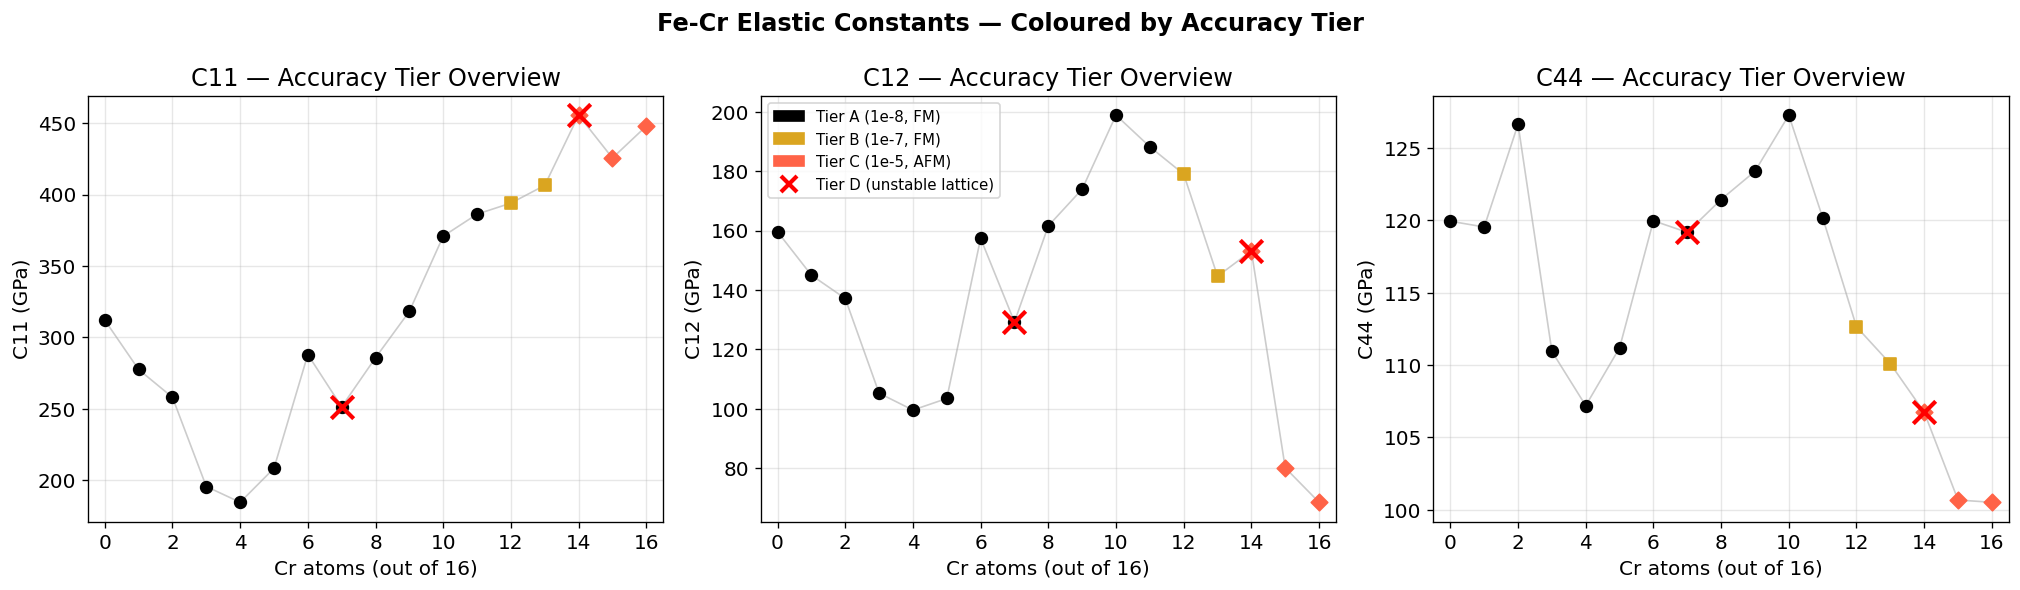

Saved: uncertainty_elastic_constants.png


In [16]:
# Assign plot markers per tier + Tier D overlay
TIER_STYLE = {
    'A': {'color':'black',     'marker':'o', 'ms':7,  'label':'Tier A (1e-8, FM)'},
    'B': {'color':'goldenrod', 'marker':'s', 'ms':7,  'label':'Tier B (1e-7, FM)'},
    'C': {'color':'tomato',    'marker':'D', 'ms':7,  'label':'Tier C (1e-5, AFM)'},
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, tname in zip(axes, TARGETS):
    y   = targets[tname]
    col = PALETTE[tname]

    # Plot by tier
    for t_lbl, style in TIER_STYLE.items():
        m = tier == t_lbl
        ax.scatter(N_CR[m], y[m],
                   color=style['color'], marker=style['marker'],
                   s=style['ms']**2, zorder=5, label=style['label'])

    # Overlay Tier D tags with red X
    for d_tag in TIER_D_TAGS:
        mask = df['tag'] == d_tag
        if mask.any():
            ncr_d = df.loc[mask, 'n_cr'].values[0]
            y_d   = y[df['tag'].values == d_tag][0]
            ax.scatter(ncr_d, y_d, color='red', marker='x',
                       s=180, linewidths=2.5, zorder=8,
                       label='Tier D (unstable lattice)' if d_tag==TIER_D_TAGS[0] else '')

    # Connect all points with thin line to show trend
    sort_idx = np.argsort(N_CR)
    ax.plot(N_CR[sort_idx], y[sort_idx], '-', color='gray',
            alpha=0.4, lw=1, zorder=1)

    ax.set_xlabel('Cr atoms (out of 16)')
    ax.set_ylabel(f'{tname} (GPa)')
    ax.set_title(f'{tname} — Accuracy Tier Overview')
    ax.set_xlim(-0.5, 16.5)
    ax.grid(alpha=0.3)

handles = [mpatches.Patch(**{k:v for k,v in s.items() if k in ['color','label']})
           for s in TIER_STYLE.values()]
handles.append(plt.Line2D([0],[0], marker='x', color='red', ms=10, lw=0,
               markeredgewidth=2.5, label='Tier D (unstable lattice)'))
axes[1].legend(handles=handles, fontsize=9, loc='best')

plt.suptitle('Fe-Cr Elastic Constants — Coloured by Accuracy Tier', fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/uncertainty_elastic_constants.png', bbox_inches='tight')
plt.show()
print('Saved: uncertainty_elastic_constants.png')


---
## Part 5 — Polynomial (deg 2 & 3) + Cubic Spline Fits

**Two fit runs per model:**
- **Run A:** exclude only fe09cr07 and fe02cr14 (Tier D tags)
- **Run B:** additionally exclude fe06cr10 (boundary tag)

**Three models per run:**
- Polynomial degree 2
- Polynomial degree 3
- Cubic spline (scipy CubicSpline, not-a-knot boundary condition)

**Plots:** All fits superimposed on one axes per elastic constant.
Residuals at Tier D tags computed for each model → empirical σ.

**The spread between polynomial deg 2, deg 3, and spline** bounds the
sensitivity of the anomaly estimate to the choice of reference curve.


In [17]:
def fit_and_predict(x_fit, y_fit, x_pred, degree=3):
    """Fit polynomial of given degree and predict at x_pred."""
    coeffs = np.polyfit(x_fit, y_fit, degree)
    return np.polyval(coeffs, x_pred)


def spline_and_predict(x_fit, y_fit, x_pred):
    """Fit cubic spline and predict at x_pred. Requires sorted x."""
    sort_idx = np.argsort(x_fit)
    cs = CubicSpline(x_fit[sort_idx], y_fit[sort_idx], bc_type='not-a-knot')
    return cs(x_pred)


# ── Define fit subsets ────────────────────────────────────────────────────────
x_all = N_CR.astype(float)

# TIER_D_TAGS are the two tags whose vcr final sanity SCF did not converge
# identified empirically from vcr_df: fe09cr07 (iteration budget) and
# fe02cr14 (physics/AFM boundary)
TIER_D_TAGS = vcr_df[~vcr_df['final_scf_ok']]['tag'].tolist()
print(f'Tier D tags (vcr not converged): {TIER_D_TAGS}')

# Run 1: all 17 tags — no exclusion
mask_all = np.ones(len(df), dtype=bool)

# Run 2: exclude Tier D (vcr not converged)
mask_excl = ~np.isin(df['tag'].values, TIER_D_TAGS)

print(f'\nRun 1 (all tags): {mask_all.sum()} tags')
print(f'Run 2 (excl. vcr-failed): {mask_excl.sum()} tags')
print(f'  Excluded: {TIER_D_TAGS}')
print(f'  Remaining: {df["tag"][mask_excl].tolist()}')

# ── Dense grid for smooth curves ──────────────────────────────────────────────
x_dense = np.linspace(0, 16, 300)

# ── Tier D evaluation points (for residual computation in Run 2) ──────────────
tier_d_ncr = {tag: df.loc[df['tag']==tag, 'n_cr'].values[0] for tag in TIER_D_TAGS}
tier_d_idx = {tag: np.where(df['tag'].values==tag)[0][0]    for tag in TIER_D_TAGS}

Tier D tags (vcr not converged): ['fe09cr07', 'fe02cr14']

Run 1 (all tags): 17 tags
Run 2 (excl. vcr-failed): 15 tags
  Excluded: ['fe09cr07', 'fe02cr14']
  Remaining: ['fe16cr00', 'fe15cr01', 'fe14cr02', 'fe13cr03', 'fe12cr04', 'fe11cr05', 'fe10cr06', 'fe08cr08', 'fe07cr09', 'fe06cr10', 'fe05cr11', 'fe04cr12', 'fe03cr13', 'fe01cr15', 'fe00cr16']


In [18]:
# ── Fit all models, collect residuals ─────────────────────────────────────────
MODELS = [
    ('Poly-2', 'royalblue',  '--', lambda xf,yf,xp: fit_and_predict(xf,yf,xp,degree=2)),
    ('Poly-3', 'darkorange', '-.', lambda xf,yf,xp: fit_and_predict(xf,yf,xp,degree=3)),
    ('Spline', 'seagreen',   '-',  lambda xf,yf,xp: spline_and_predict(xf,yf,xp)),
]

RUNS = [
    ('All 17',   mask_all,  'all tags included'),
    ('Excl. vcr-failed', mask_excl, 'fe09cr07 and fe02cr14 excluded'),
]

# curves[tname][(mname, rname)]  = (x_dense, y_dense)
# residuals[tname][mname][rname] = {tag: residual_gpa}
# Residuals only meaningful for Run 2 (excl.) — predicting at excluded points
curves    = {tname: {} for tname in TARGETS}
residuals = {tname: {m[0]: {} for m in MODELS} for tname in TARGETS}

for tname in TARGETS:
    y = targets[tname]
    for mname, _, _, mfn in MODELS:
        for rname, rmask, _ in RUNS:
            x_fit        = x_all[rmask]
            y_fit        = y[rmask]
            y_dense_pred = mfn(x_fit, y_fit, x_dense)
            curves[tname][(mname, rname)] = (x_dense, y_dense_pred)

            # Residuals at Tier D tags — only meaningful when they are excluded
            resid_run = {}
            if rname == 'Excl. vcr-failed':
                for tag in TIER_D_TAGS:
                    ncr              = tier_d_ncr[tag]
                    y_pred           = mfn(x_fit, y_fit, np.array([float(ncr)]))[0]
                    y_true           = y[tier_d_idx[tag]]
                    resid_run[tag]   = y_true - y_pred
            residuals[tname][mname][rname] = resid_run

print('Fits computed.')
print('\nResiduals at Tier D tags (Run 2 — excluded from fit):')
for tname in TARGETS:
    print(f'\n  {tname}:')
    for mname, _, _, _ in MODELS:
        resid = residuals[tname][mname]['Excl. vcr-failed']
        if resid:
            rstr = '  '.join([f'{tag}: {v:+.2f} GPa' for tag, v in resid.items()])
            print(f'    {mname:8s}: {rstr}')

Fits computed.

Residuals at Tier D tags (Run 2 — excluded from fit):

  C11:
    Poly-2  : fe09cr07: -27.74 GPa  fe02cr14: +35.80 GPa
    Poly-3  : fe09cr07: -11.66 GPa  fe02cr14: +19.02 GPa
    Spline  : fe09cr07: -48.76 GPa  fe02cr14: +40.47 GPa

  C12:
    Poly-2  : fe09cr07: -33.68 GPa  fe02cr14: +29.72 GPa
    Poly-3  : fe09cr07: -18.91 GPa  fe02cr14: +14.30 GPa
    Spline  : fe09cr07: -42.04 GPa  fe02cr14: +45.80 GPa

  C44:
    Poly-2  : fe09cr07: -0.87 GPa  fe02cr14: -1.58 GPa
    Poly-3  : fe09cr07: +1.04 GPa  fe02cr14: -3.57 GPa
    Spline  : fe09cr07: -3.31 GPa  fe02cr14: +1.25 GPa


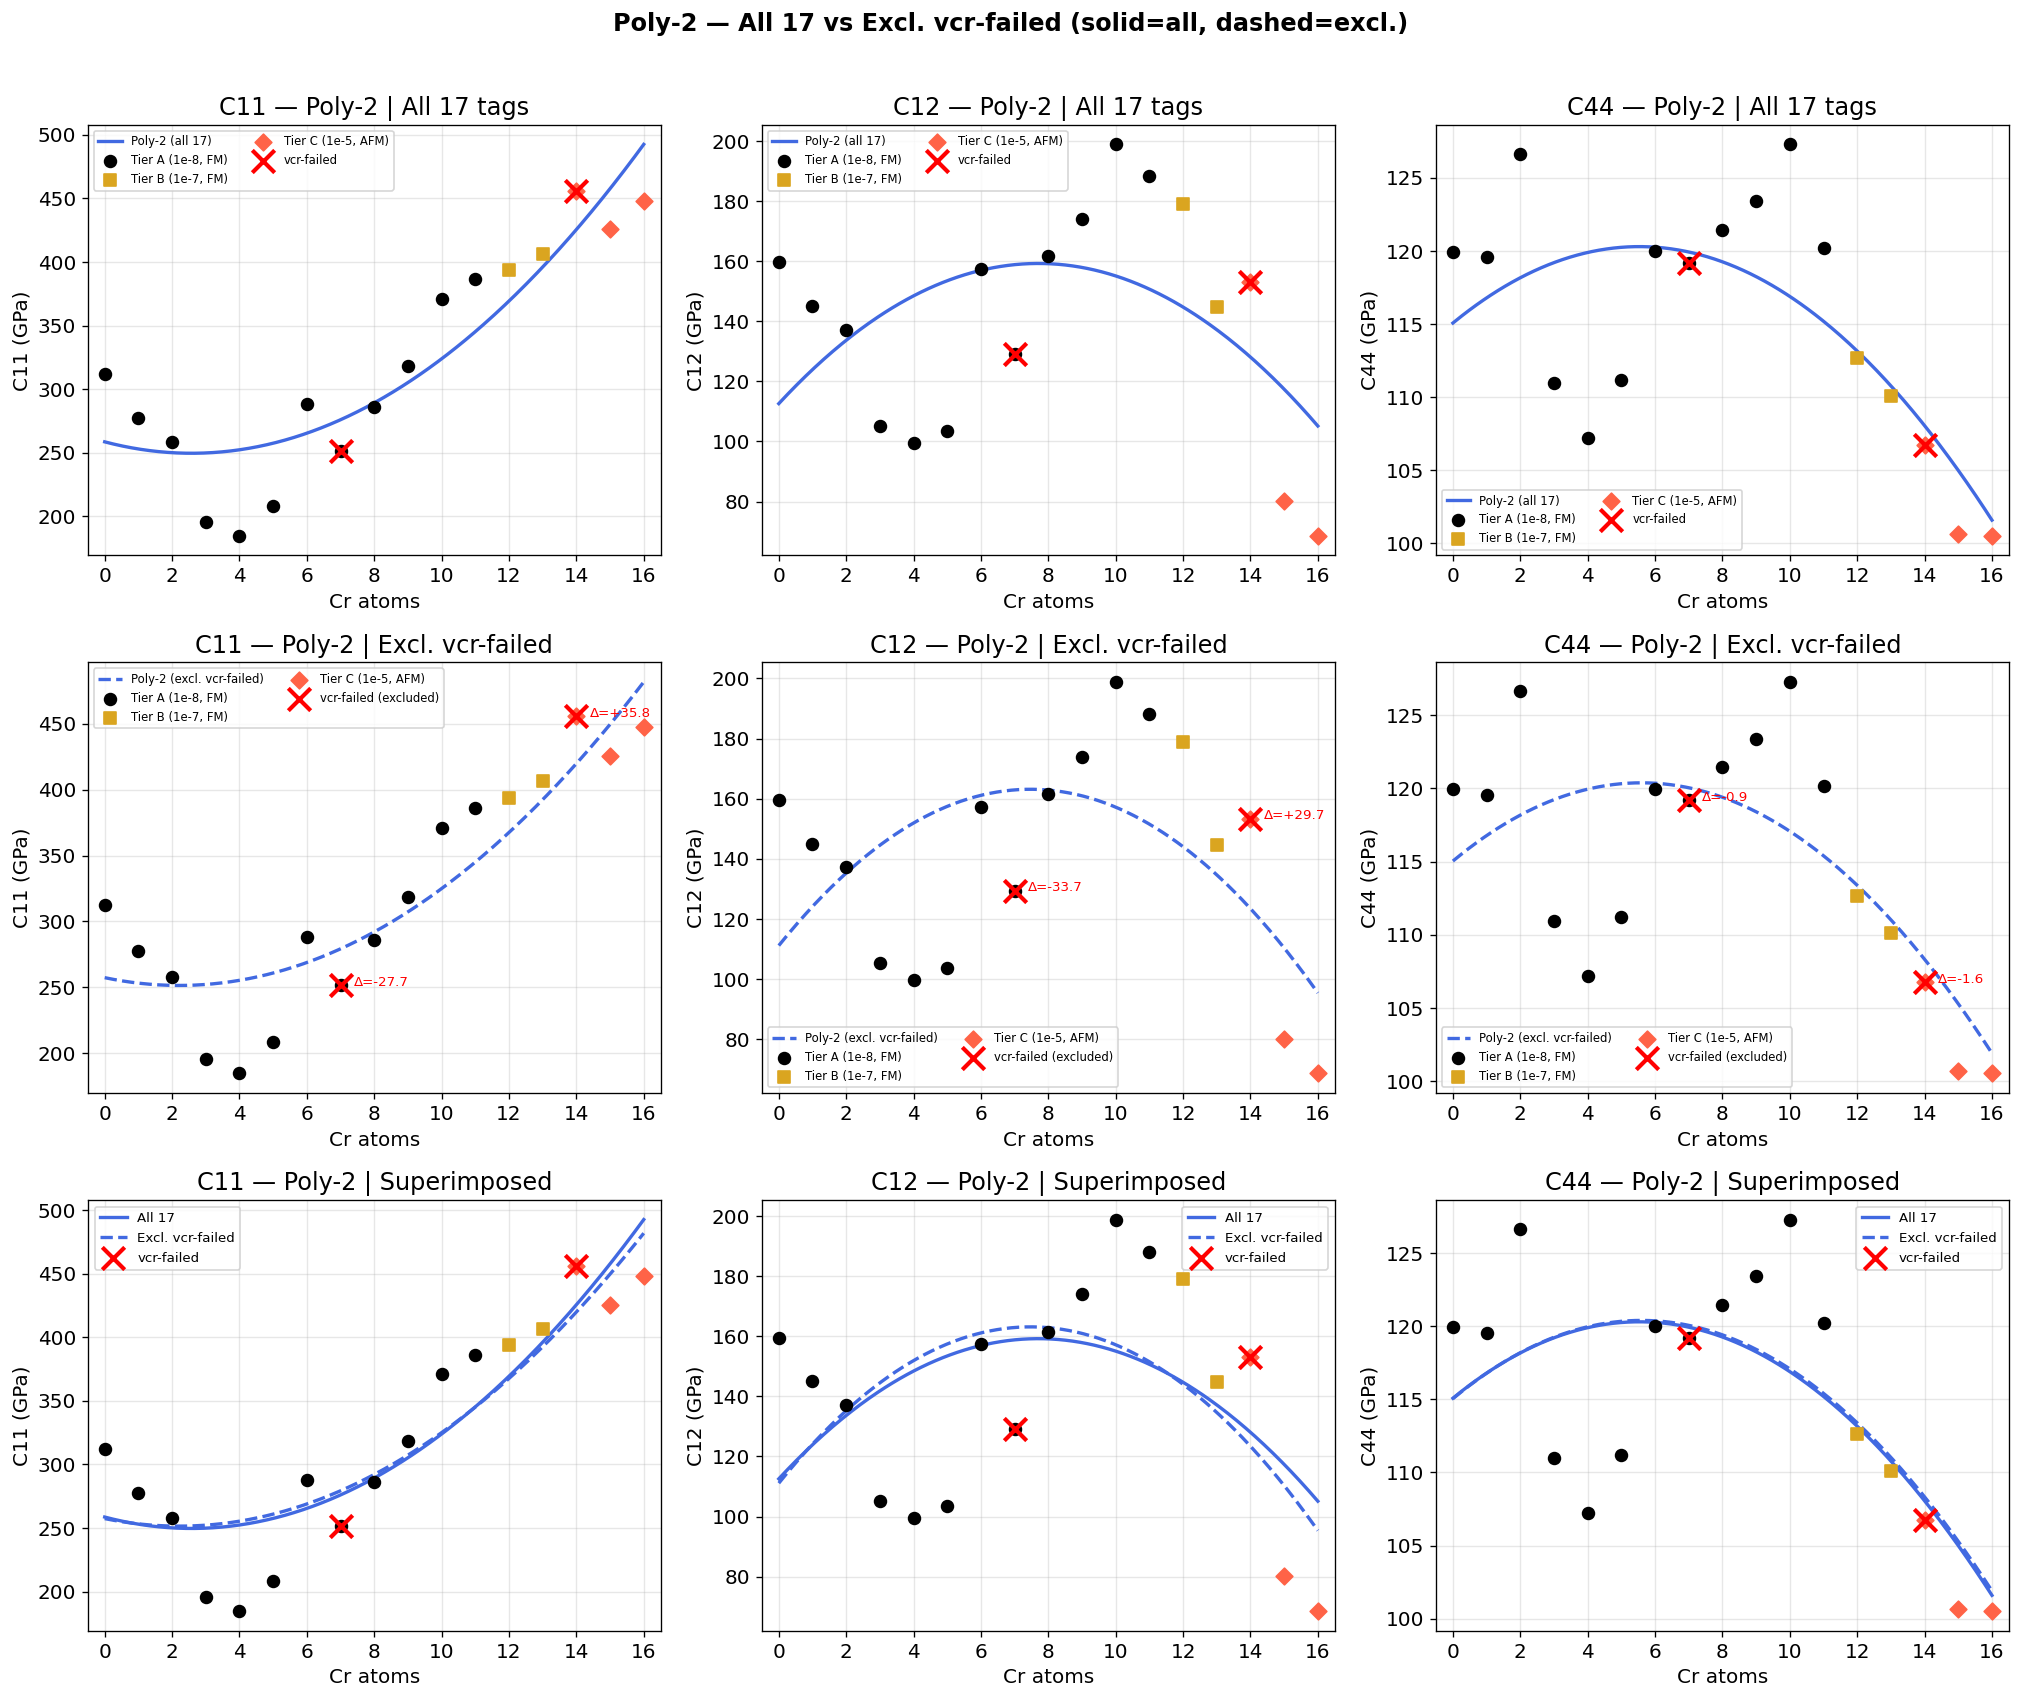

Saved: ../analysis/uncertainty_fits_poly2.png


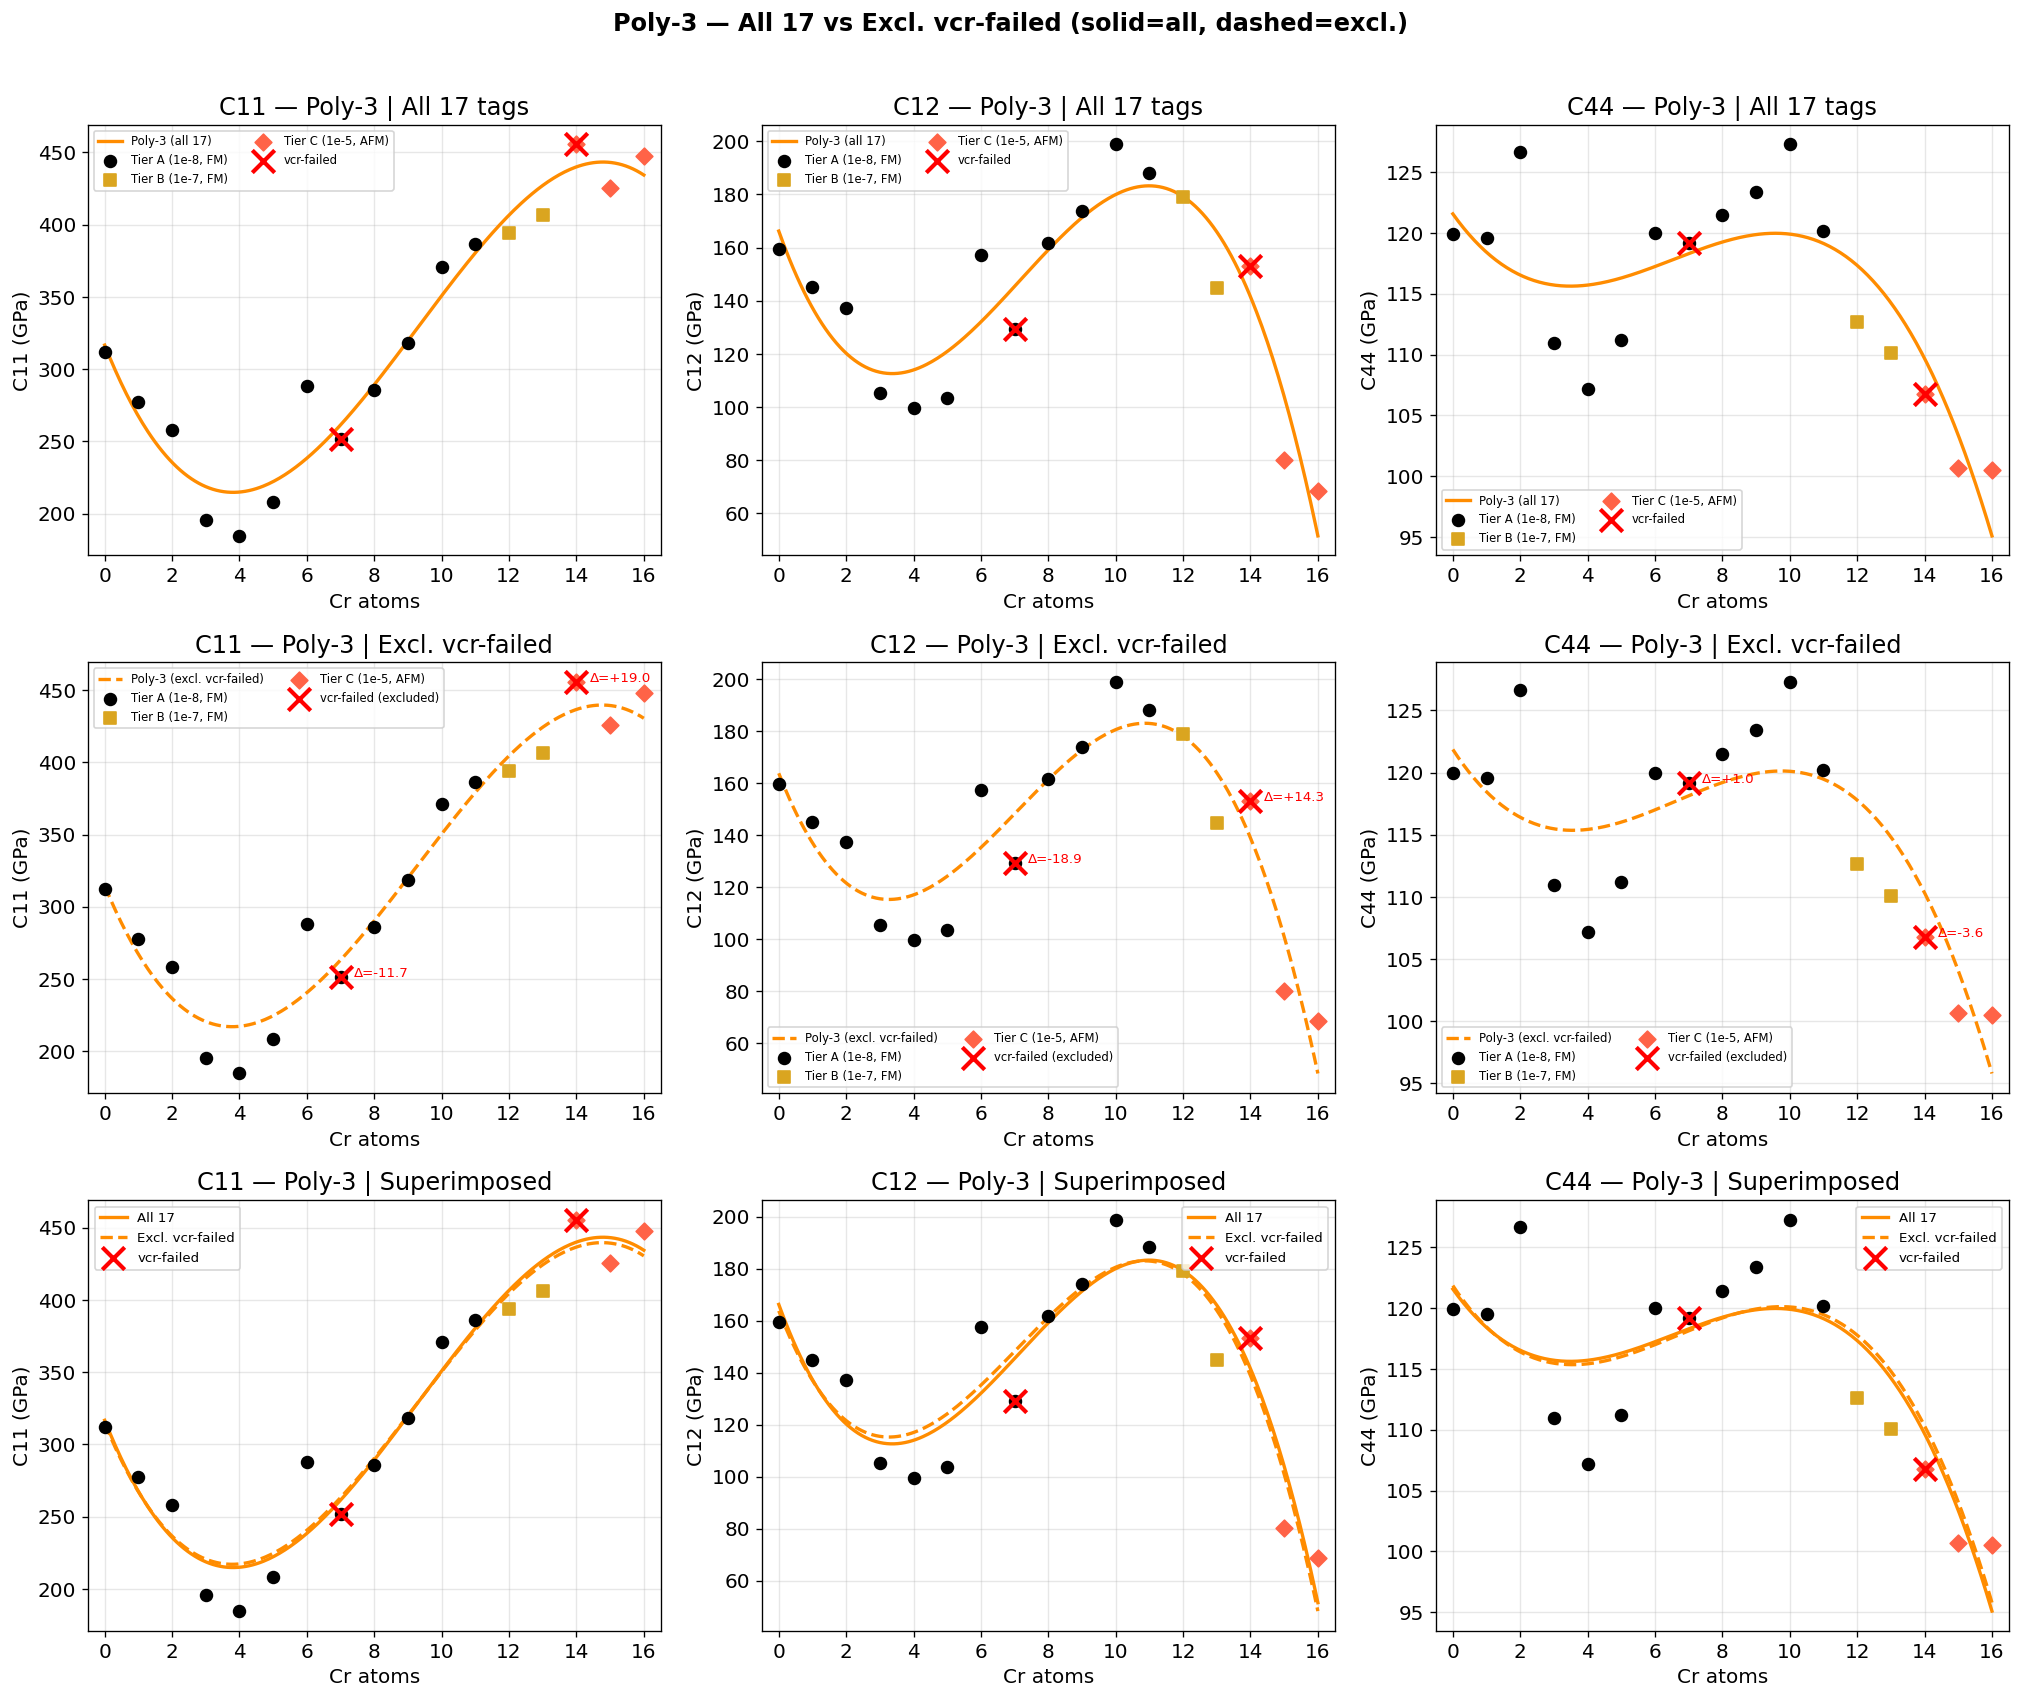

Saved: ../analysis/uncertainty_fits_poly3.png


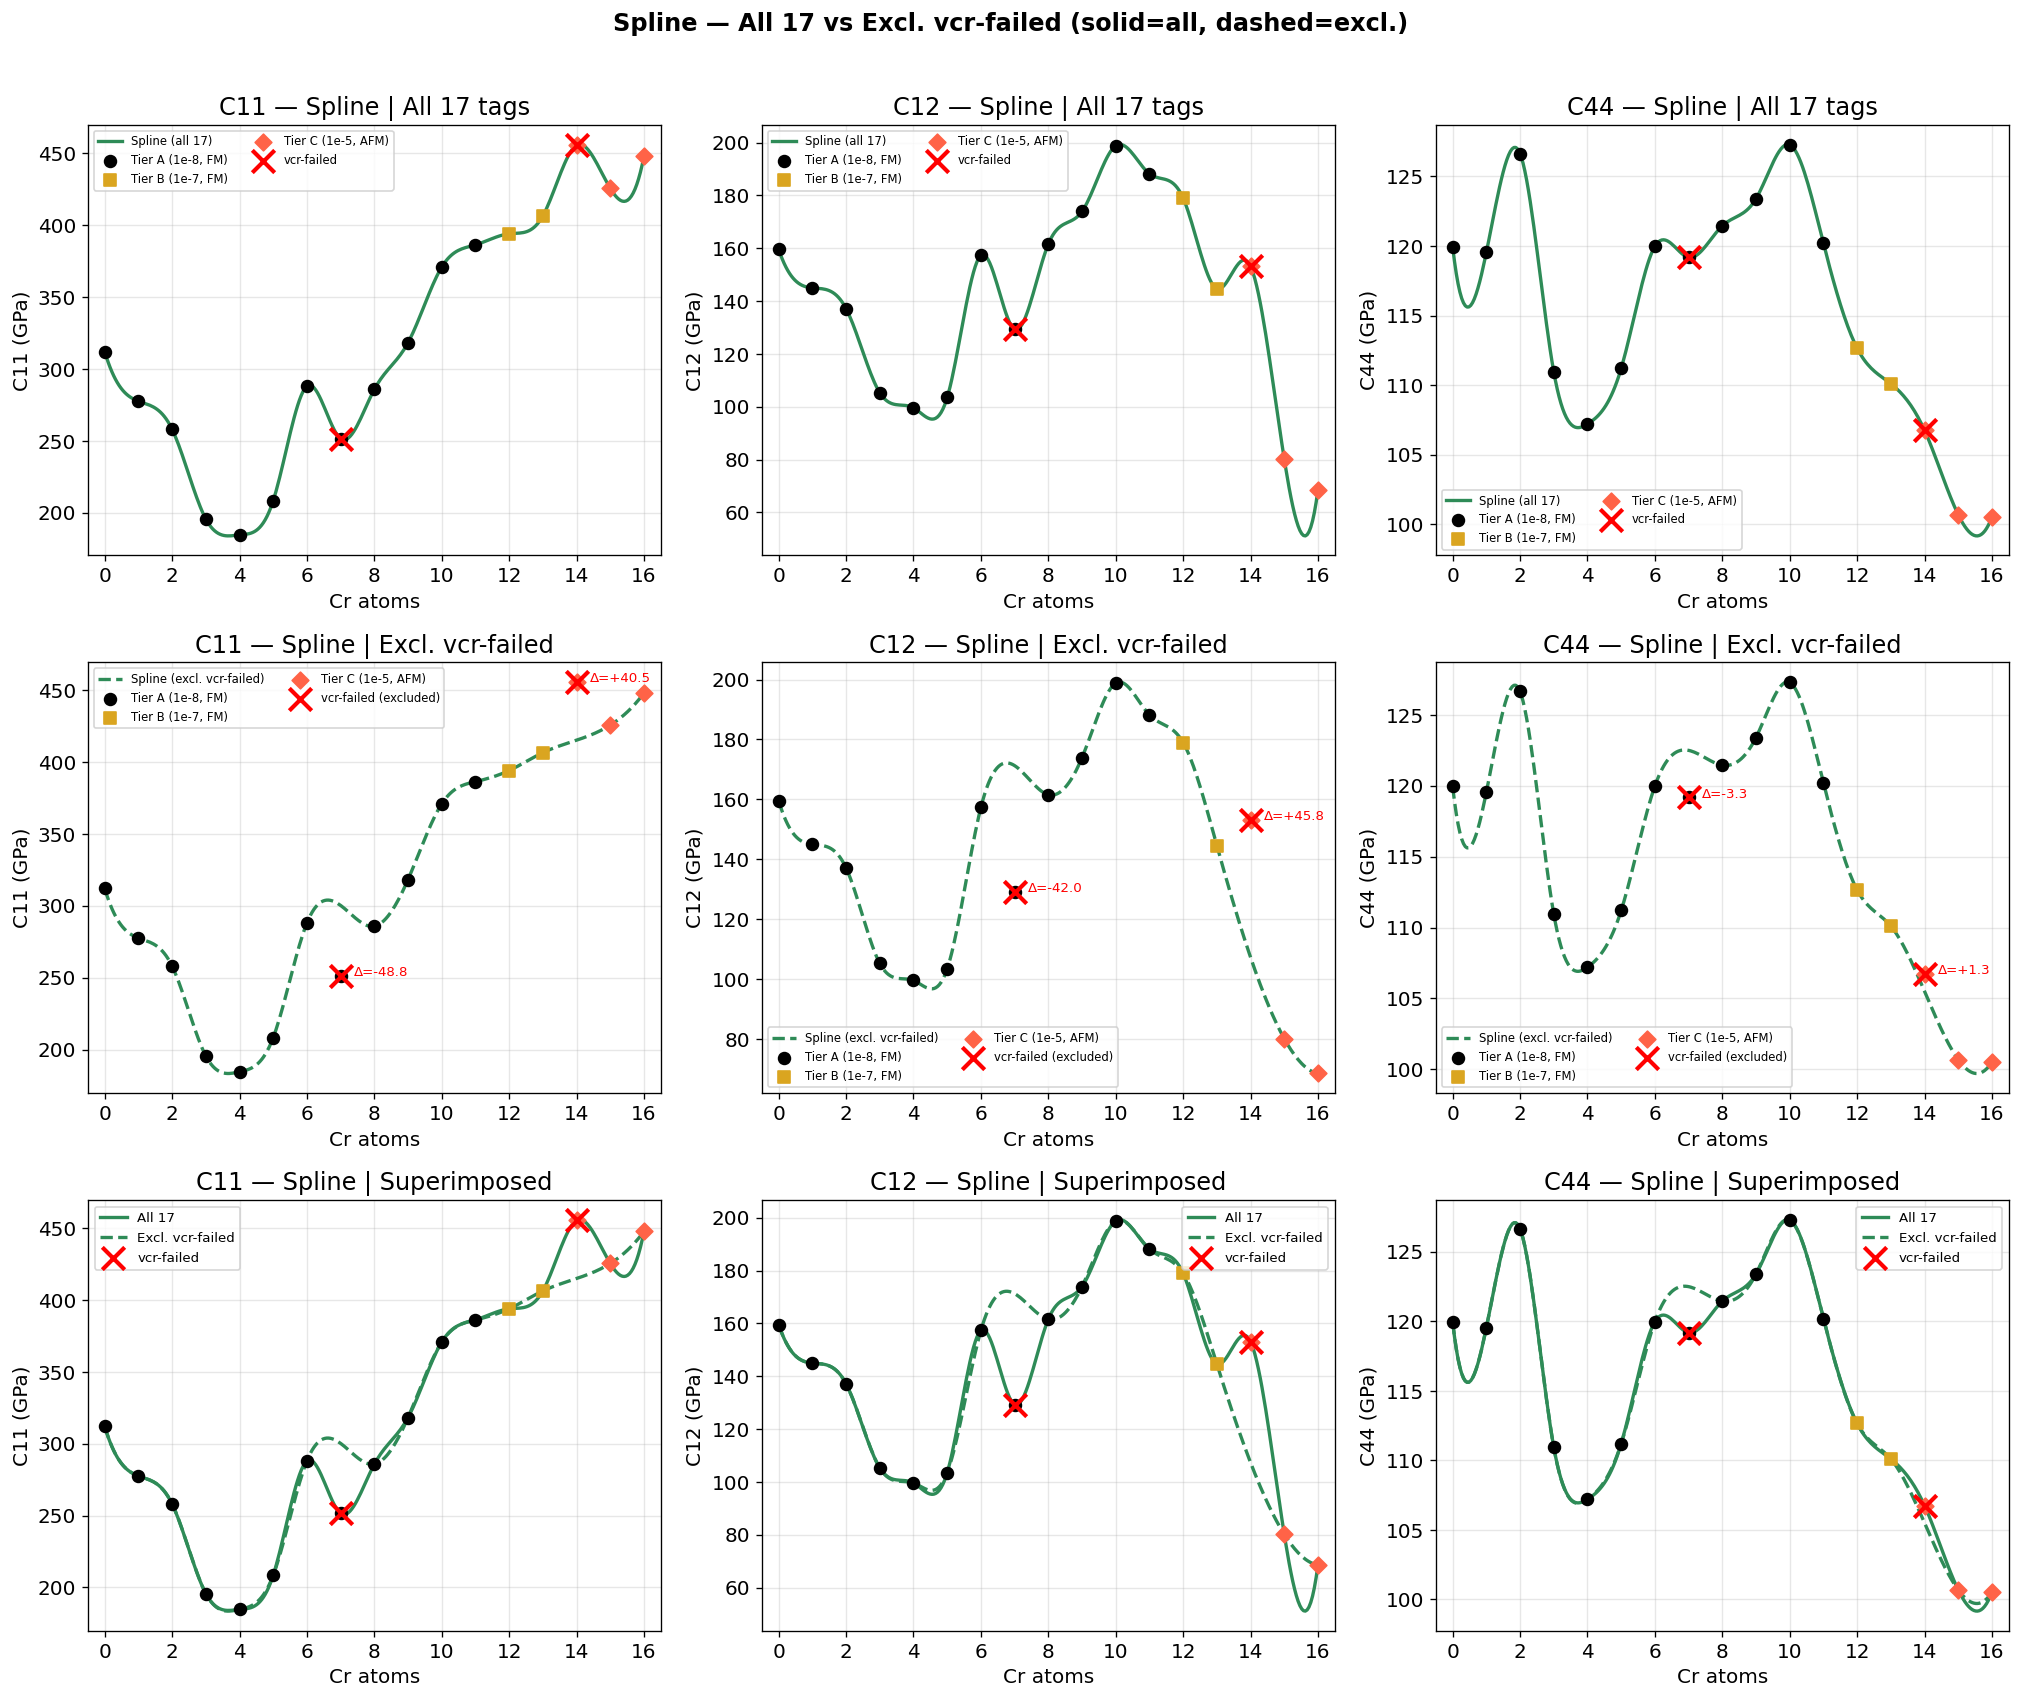

Saved: ../analysis/uncertainty_fits_spline.png


In [19]:
# ── Plots: 3 figures per model (all 17, excl. vcr-failed, superimposed) ───────
# For each model (Poly-2, Poly-3, Spline):
#   Plot 1: fit on all 17 tags
#   Plot 2: fit excluding vcr-failed (Tier D) tags
#   Plot 3: both curves superimposed

MODEL_COLOURS = {'Poly-2': 'royalblue', 'Poly-3': 'darkorange', 'Spline': 'seagreen'}
RUN_LS        = {'All 17': 'solid', 'Excl. vcr-failed': 'dashed'}
RUN_LW        = {'All 17': 2.0,     'Excl. vcr-failed': 2.0}

for mname, _, _, _ in MODELS:
    col = MODEL_COLOURS[mname]

    # 3 plot types × 3 elastic constants = 3 rows of subplots
    fig, axes = plt.subplots(3, 3, figsize=(17, 14))

    for col_idx, tname in enumerate(TARGETS):
        y = targets[tname]

        # ── Plot 1: all 17 tags ───────────────────────────────────────────────
        ax1 = axes[0, col_idx]
        xc, yc = curves[tname][(mname, 'All 17')]
        ax1.plot(xc, yc, color=col, ls='solid', lw=2.0, label=f'{mname} (all 17)')
        for t_lbl, style in TIER_STYLE.items():
            m = tier == t_lbl
            ax1.scatter(x_all[m], y[m], color=style['color'],
                        marker=style['marker'], s=50, zorder=5, label=style['label'])
        for tag in TIER_D_TAGS:
            ax1.scatter(tier_d_ncr[tag], y[tier_d_idx[tag]],
                        color='red', marker='x', s=180, linewidths=2.5, zorder=8,
                        label='vcr-failed' if tag == TIER_D_TAGS[0] else '')
        ax1.set_title(f'{tname} — {mname} | All 17 tags')
        ax1.set_xlabel('Cr atoms'); ax1.set_ylabel(f'{tname} (GPa)')
        ax1.set_xlim(-0.5, 16.5); ax1.grid(alpha=0.3)
        ax1.legend(fontsize=7, ncol=2)

        # ── Plot 2: excluding vcr-failed ──────────────────────────────────────
        ax2 = axes[1, col_idx]
        xc, yc = curves[tname][(mname, 'Excl. vcr-failed')]
        ax2.plot(xc, yc, color=col, ls='dashed', lw=2.0, label=f'{mname} (excl. vcr-failed)')
        for t_lbl, style in TIER_STYLE.items():
            m = tier == t_lbl
            ax2.scatter(x_all[m], y[m], color=style['color'],
                        marker=style['marker'], s=50, zorder=5, label=style['label'])
        for tag in TIER_D_TAGS:
            ax2.scatter(tier_d_ncr[tag], y[tier_d_idx[tag]],
                        color='red', marker='x', s=180, linewidths=2.5, zorder=8,
                        label='vcr-failed (excluded)' if tag == TIER_D_TAGS[0] else '')
            # Show residual annotation
            resid = residuals[tname][mname]['Excl. vcr-failed'].get(tag)
            if resid is not None:
                ax2.annotate(f'Δ={resid:+.1f}',
                             xy=(tier_d_ncr[tag], y[tier_d_idx[tag]]),
                             xytext=(tier_d_ncr[tag] + 0.4, y[tier_d_idx[tag]]),
                             fontsize=8, color='red')
        ax2.set_title(f'{tname} — {mname} | Excl. vcr-failed')
        ax2.set_xlabel('Cr atoms'); ax2.set_ylabel(f'{tname} (GPa)')
        ax2.set_xlim(-0.5, 16.5); ax2.grid(alpha=0.3)
        ax2.legend(fontsize=7, ncol=2)

        # ── Plot 3: superimposed ──────────────────────────────────────────────
        ax3 = axes[2, col_idx]
        for rname, ls in RUN_LS.items():
            xc, yc = curves[tname][(mname, rname)]
            lbl = 'All 17' if rname == 'All 17' else 'Excl. vcr-failed'
            ax3.plot(xc, yc, color=col, ls=ls, lw=2.0, label=lbl)
        for t_lbl, style in TIER_STYLE.items():
            m = tier == t_lbl
            ax3.scatter(x_all[m], y[m], color=style['color'],
                        marker=style['marker'], s=50, zorder=5)
        for tag in TIER_D_TAGS:
            ax3.scatter(tier_d_ncr[tag], y[tier_d_idx[tag]],
                        color='red', marker='x', s=180, linewidths=2.5, zorder=8,
                        label='vcr-failed' if tag == TIER_D_TAGS[0] else '')
        ax3.set_title(f'{tname} — {mname} | Superimposed')
        ax3.set_xlabel('Cr atoms'); ax3.set_ylabel(f'{tname} (GPa)')
        ax3.set_xlim(-0.5, 16.5); ax3.grid(alpha=0.3)
        ax3.legend(fontsize=8)

    plt.suptitle(f'{mname} — All 17 vs Excl. vcr-failed (solid=all, dashed=excl.)',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = f'../analysis/uncertainty_fits_{mname.lower().replace("-","")}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

In [20]:
# ── Residual summary table ────────────────────────────────────────────────────
# Residuals only from Run 2 (Excl. vcr-failed) — Run 1 includes these points
# in the fit so its residuals are not meaningful as uncertainty estimates.
print('=== Residuals at Tier D tags — Run 2 (excluded from fit) ===')
print('Positive = point lies ABOVE the reference curve (stiffer than expected)')
print('Negative = point lies BELOW the reference curve (softer than expected)')
print()

rows = []
for tname in TARGETS:
    for mname, _, _, _ in MODELS:
        for tag in TIER_D_TAGS:
            r = residuals[tname][mname]['Excl. vcr-failed'].get(tag)
            if r is not None:
                rows.append({'target':          tname,
                             'model':           mname,
                             'tag':             tag,
                             'residual_gpa':    round(r, 3),
                             'abs_residual_gpa':round(abs(r), 3)})

resid_df = pd.DataFrame(rows)
pivot_r  = resid_df.pivot_table(
    index=['tag', 'target'],
    columns='model',
    values='abs_residual_gpa'
)
print(pivot_r.to_string())
print()

# Per tag: max and mean absolute residual across models → σ range
print('=== Anomaly bounds per tag (across Poly-2, Poly-3, Spline) ===')
print('These are empirical σ estimates for Tier D uncertainty.')
print('Spread across models bounds the sensitivity to reference curve choice.')
for tag in TIER_D_TAGS:
    sub = resid_df[resid_df['tag'] == tag]
    print(f'\n  {tag}:')
    for tname in TARGETS:
        vals = sub[sub['target'] == tname]['abs_residual_gpa']
        if not vals.empty:
            print(f'    {tname}: min={vals.min():.2f}  max={vals.max():.2f}  '
                  f'mean={vals.mean():.2f} GPa  '
                  f'[spread={vals.max()-vals.min():.2f} GPa across models]')

=== Residuals at Tier D tags — Run 2 (excluded from fit) ===
Positive = point lies ABOVE the reference curve (stiffer than expected)
Negative = point lies BELOW the reference curve (softer than expected)

model            Poly-2  Poly-3  Spline
tag      target                        
fe02cr14 C11      4e+01   2e+01   4e+01
         C12      3e+01   1e+01   5e+01
         C44      2e+00   4e+00   1e+00
fe09cr07 C11      3e+01   1e+01   5e+01
         C12      3e+01   2e+01   4e+01
         C44      9e-01   1e+00   3e+00

=== Anomaly bounds per tag (across Poly-2, Poly-3, Spline) ===
These are empirical σ estimates for Tier D uncertainty.
Spread across models bounds the sensitivity to reference curve choice.

  fe09cr07:
    C11: min=11.66  max=48.76  mean=29.39 GPa  [spread=37.10 GPa across models]
    C12: min=18.91  max=42.03  mean=31.54 GPa  [spread=23.13 GPa across models]
    C44: min=0.87  max=3.31  mean=1.74 GPa  [spread=2.44 GPa across models]

  fe02cr14:
    C11: min=19.02  ma

---
## Part 6 — fe06cr10 Boundary Analysis (1e-8 vs 1e-7)

fe06cr10 straddles the 1e-8/1e-7 boundary. From Part 1 we know exactly
which of its calculations used which threshold.

Here we compare the **stress values** (from .dat files) of fe06cr10 against
its immediate neighbours fe07cr09 and fe05cr11 to see if the threshold
change introduced any visible discontinuity at this tag specifically.

We also compute what C11+2C12, C11-C12, C44 would be from fe06cr10's
`.dat` files and compare against the smooth reference curve from Part 5.


In [22]:
""" # ── Which calculations in fe06cr10 used which conv_thr? ──────────────────────
fe06_calcs = calc_df[calc_df['tag']=='fe06cr10'].copy()
print('=== fe06cr10 per-calculation conv_thr ===')
print(fe06_calcs[['strain_type','epsilon','conv_thr','file_found']].to_string(index=False))

# Group by conv_thr
print('\nCalculations at 1e-8:')
print(fe06_calcs[fe06_calcs['conv_thr']==1e-8][['strain_type','epsilon']].to_string(index=False))
print('\nCalculations at 1e-7 (or other):')
print(fe06_calcs[fe06_calcs['conv_thr']!=1e-8][['strain_type','epsilon','conv_thr']].to_string(index=False)) """


" # ── Which calculations in fe06cr10 used which conv_thr? ──────────────────────\nfe06_calcs = calc_df[calc_df['tag']=='fe06cr10'].copy()\nprint('=== fe06cr10 per-calculation conv_thr ===')\nprint(fe06_calcs[['strain_type','epsilon','conv_thr','file_found']].to_string(index=False))\n\n# Group by conv_thr\nprint('\nCalculations at 1e-8:')\nprint(fe06_calcs[fe06_calcs['conv_thr']==1e-8][['strain_type','epsilon']].to_string(index=False))\nprint('\nCalculations at 1e-7 (or other):')\nprint(fe06_calcs[fe06_calcs['conv_thr']!=1e-8][['strain_type','epsilon','conv_thr']].to_string(index=False)) "

In [25]:
print(f'fe06_results length: {len(fe06_results)}')
if len(fe06_results) == 0:
    print('All stress_interp_analysis calls returned None')
    print('Debugging first call:')
    stype = 'h'
    eps   = -0.01
    ref_mask = (
        (calc_df['strain_type'] == stype) &
        (calc_df['epsilon']     == eps) &
        (calc_df['conv_thr']    == 1e-8) &
        (calc_df['tag']         != 'fe06cr10')
    )
    print(f'  ref_mask matches: {ref_mask.sum()} rows')
    print(f'  calc_df strain_type unique: {calc_df["strain_type"].unique()}')
    print(f'  calc_df epsilon unique: {sorted(calc_df["epsilon"].dropna().unique())}')
    print(f'  calc_df conv_thr unique: {sorted(calc_df["conv_thr"].dropna().unique())}')
    print(f'  Sample calc_df rows:')
    print(calc_df[['tag','strain_type','epsilon','conv_thr']].head(10).to_string())
    
    # Test read_stress_value directly
    test_val = read_stress_value('fe16cr00', 'h', -0.01, DAT_ROOT)
    print(f'\n  read_stress_value fe16cr00 h -0.01: {test_val}')
    print(f'  DAT_ROOT exists: {os.path.exists(DAT_ROOT)}')
    print(f'  Sample dat files: {os.listdir(DAT_ROOT)[:5]}')

fe06_results length: 0
All stress_interp_analysis calls returned None
Debugging first call:
  ref_mask matches: 10 rows
  calc_df strain_type unique: <StringArray>
['h', 's', 't', 'vcr']
Length: 4, dtype: str
  calc_df epsilon unique: [-0.01, 0.0, 0.01]
  calc_df conv_thr unique: [1e-08, 1e-07, 1e-05]
  Sample calc_df rows:
        tag strain_type  epsilon  conv_thr
0  fe16cr00           h   -1e-02     1e-08
1  fe16cr00           h    0e+00     1e-08
2  fe16cr00           h    1e-02     1e-08
3  fe16cr00           s   -1e-02     1e-08
4  fe16cr00           s    0e+00     1e-08
5  fe16cr00           s    1e-02     1e-08
6  fe16cr00           t   -1e-02     1e-08
7  fe16cr00           t    0e+00     1e-08
8  fe16cr00           t    1e-02     1e-08
9  fe15cr01           h   -1e-02     1e-08

  read_stress_value fe16cr00 h -0.01: None
  DAT_ROOT exists: True
  Sample dat files: ['fecr_fe09cr07_shear.dat', 'fecr_fe04cr12_shear.dat', 'fecr_fe09cr07_hydro.dat', 'fecr_fe14cr02_shear.dat', 'fec

In [26]:
# ── Per-calculation stress interpolation: fe06cr10 and fe02cr14 ───────────────
#
# Principle: fit same (strain_type, epsilon) stress values from tags at the
# reference threshold, predict at the boundary tag composition, compare to
# actual stress. Δ = empirical uncertainty from threshold change at that calc.
#
# Stress columns read from .dat files:
#   hydro : col 1 = pressure P (kbar)
#   shear : col 1 = S12 (kbar)
#   tetra : col 3 = DS = S33-S11 (kbar)  ← feeds C11-C12
#
# fe06cr10 (n_cr=10): all strain calcs at 1e-7, vcr at 1e-8
#   Reference: same (stype, eps) calcs at 1e-8 → tags n_cr 0-9
#
# fe02cr14 (n_cr=14): h±0.01 at 1e-7, rest at 1e-5
#   For 1e-7 calcs: reference = same type at 1e-7 → tags n_cr 10-13
#   For 1e-5 calcs: reference = same type at 1e-7 → tags n_cr 10-13
#   For h0.00: also direct comparison via fecr_fe02cr14_h0.00_thr7.out

DAT_ROOT = '../dft_data'

def read_stress_value(tag, strain_type, eps, dat_root):
    """
    Read stress value for a given (tag, strain_type, epsilon) from .dat file.
    Returns stress in kbar, or None if file/row missing.
      hydro (h) → P       (col 1)
      shear (s) → S12     (col 1)
      tetra (t) → DS=S33-S11 (col 3)
    Filename pattern: fecr_{tag}_hydro/shear/tetra.dat
    """
    stype_map = {'h': 'hydro', 's': 'shear', 't': 'tetra'}
    sname = stype_map.get(strain_type)
    if sname is None:
        return None
    fname = os.path.join(dat_root, f'fecr_{tag}_{sname}.dat')
    if not os.path.exists(fname):
        return None
    data = np.loadtxt(fname)
    data = data[data[:, 0].argsort()]
    row  = data[np.isclose(data[:, 0], eps, atol=1e-4)]
    if len(row) == 0:
        return None
    if strain_type == 'h': return float(row[0, 1])
    if strain_type == 's': return float(row[0, 1])
    if strain_type == 't': return float(row[0, 3])
    return None


def stress_interp_analysis(target_tag, target_ncr, ref_tags_mask,
                            strain_type, eps, dat_root, label):
    """
    Fit poly-2, poly-3, spline on reference tags' stress values,
    predict at target_ncr, compare to actual stress.
    Returns dict with actual, predicted (per model), and Δ values.
    """
    # Reference points
    ref_tags = df.loc[ref_tags_mask, 'tag'].values
    ref_ncr  = df.loc[ref_tags_mask, 'n_cr'].values.astype(float)
    ref_stress = []
    for t in ref_tags:
        v = read_stress_value(t, strain_type, eps, dat_root)
        ref_stress.append(v)
    ref_stress = np.array(ref_stress, dtype=float)

    # Drop any None
    valid = ~np.isnan(ref_stress)
    if valid.sum() < 3:
        return None
    xf = ref_ncr[valid]
    yf = ref_stress[valid]
    xt = np.array([float(target_ncr)])

    actual = read_stress_value(target_tag, strain_type, eps, dat_root)
    if actual is None:
        return None

    result = {'label': label, 'strain_type': strain_type, 'epsilon': eps,
              'actual_kbar': actual, 'n_ref': valid.sum()}
    for mname, mfn in [
        ('Poly-2', lambda x,y,xp: fit_and_predict(x,y,xp,degree=2)),
        ('Poly-3', lambda x,y,xp: fit_and_predict(x,y,xp,degree=3)),
        ('Spline', lambda x,y,xp: spline_and_predict(x,y,xp)),
    ]:
        try:
            pred = mfn(xf, yf, xt)[0]
            result[f'pred_{mname}_kbar'] = round(pred, 4)
            result[f'delta_{mname}_kbar'] = round(actual - pred, 4)
            result[f'delta_{mname}_gpa']  = round((actual - pred)*0.1, 4)
        except Exception:
            result[f'pred_{mname}_kbar']  = float('nan')
            result[f'delta_{mname}_kbar'] = float('nan')
            result[f'delta_{mname}_gpa']  = float('nan')
    return result


# ─────────────────────────────────────────────────────────────────────────────
# fe06cr10: reference = all 1e-8 strain calcs of same (stype, eps)
#           i.e. tags where that specific (stype, eps) calc was at 1e-8
# ─────────────────────────────────────────────────────────────────────────────
fe06_results = []
for stype in STRAIN_TYPES:
    for eps_str in EPSILONS:
        eps = float(eps_str)
        # Reference mask: same (stype, eps) calcs at 1e-8, excluding fe06cr10
        ref_mask = (
            (calc_df['strain_type'] == stype) &
            (calc_df['epsilon']     == eps) &
            (calc_df['conv_thr']    == 1e-8) &
            (calc_df['tag']         != 'fe06cr10')
        )
        ref_tags_bool = df['tag'].isin(calc_df.loc[ref_mask, 'tag'].values)
        res = stress_interp_analysis(
            'fe06cr10', 10, ref_tags_bool, stype, eps, DAT_ROOT,
            f'fe06cr10 {stype}{eps_str}')
        if res:
            fe06_results.append(res)

fe06_df = pd.DataFrame(fe06_results)
print('=== fe06cr10: stress interpolation from 1e-8 reference calcs ===')
print(fe06_df[['strain_type','epsilon','actual_kbar',
               'delta_Poly-2_gpa','delta_Poly-3_gpa',
               'delta_Spline_gpa']].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# fe02cr14: reference = all 1e-7 strain calcs of same (stype, eps)
#           i.e. tags fe06cr10→fe03cr13 (n_cr 10-13) at 1e-7
# ─────────────────────────────────────────────────────────────────────────────
fe02_results = []
for stype in STRAIN_TYPES:
    for eps_str in EPSILONS:
        eps = float(eps_str)
        ref_mask = (
            (calc_df['strain_type'] == stype) &
            (calc_df['epsilon']     == eps) &
            (calc_df['conv_thr']    == 1e-7) &
            (calc_df['tag']         != 'fe02cr14')
        )
        ref_tags_bool = df['tag'].isin(calc_df.loc[ref_mask, 'tag'].values)
        res = stress_interp_analysis(
            'fe02cr14', 14, ref_tags_bool, stype, eps, DAT_ROOT,
            f'fe02cr14 {stype}{eps_str}')
        if res:
            # Tag the actual conv_thr for this specific calculation
            this_thr = calc_df.loc[
                (calc_df['tag']          == 'fe02cr14') &
                (calc_df['strain_type']  == stype) &
                (calc_df['epsilon']      == eps), 'conv_thr'].values
            res['actual_conv_thr'] = this_thr[0] if len(this_thr) else float('nan')
            fe02_results.append(res)

# Direct comparison for fe02cr14 h0.00 using thr7 file
h00_thr5 = read_stress_value('fe02cr14', 'h', 0.0, DAT_ROOT)
h00_thr7 = None
thr7_path = os.path.join('../outputs', 'fecr_fe02cr14_h0.00_thr7.out')
if os.path.exists(thr7_path):
    # Parse pressure from thr7 output file
    h00_thr7 = parse_final_stress(thr7_path)
    if h00_thr7:
        h00_thr7 = h00_thr7['P_kbar']

fe02_df = pd.DataFrame(fe02_results)
print('\n=== fe02cr14: stress interpolation from 1e-7 reference calcs ===')
print(fe02_df[['strain_type','epsilon','actual_conv_thr','actual_kbar',
               'delta_Poly-2_gpa','delta_Poly-3_gpa',
               'delta_Spline_gpa']].to_string(index=False))

if h00_thr5 is not None and h00_thr7 is not None:
    direct_delta = (h00_thr5 - h00_thr7) * 0.1
    print(f'\n  fe02cr14 h0.00 direct comparison (thr5 vs thr7):')
    print(f'    P(1e-5)={h00_thr5:.3f} kbar  P(1e-7)={h00_thr7:.3f} kbar  '
          f'Δ={direct_delta:+.4f} GPa')
    print(f'    (This is exact — no interpolation)')

# ─────────────────────────────────────────────────────────────────────────────
# Summary: empirical σ per threshold from these analyses
# ─────────────────────────────────────────────────────────────────────────────
print('\n=== Empirical σ summary from per-calculation interpolation ===')
print('\nfe06cr10 (1e-8 → 1e-7 boundary):')
for col in ['delta_Poly-2_gpa','delta_Poly-3_gpa','delta_Spline_gpa']:
    vals = fe06_df[col].abs()
    print(f'  {col:22s}: mean={vals.mean():.3f}  max={vals.max():.3f} GPa')

print('\nfe02cr14 (1e-7 → 1e-5 boundary, 1e-5 calcs only):')
fe02_1e5 = fe02_df[fe02_df['actual_conv_thr']==1e-5]
for col in ['delta_Poly-2_gpa','delta_Poly-3_gpa','delta_Spline_gpa']:
    vals = fe02_1e5[col].abs()
    print(f'  {col:22s}: mean={vals.mean():.3f}  max={vals.max():.3f} GPa')

print('\nfe02cr14 (1e-7 calcs — h±0.01 — interpolation check):')
fe02_1e7 = fe02_df[fe02_df['actual_conv_thr']==1e-7]
for col in ['delta_Poly-2_gpa','delta_Poly-3_gpa','delta_Spline_gpa']:
    vals = fe02_1e7[col].abs()
    print(f'  {col:22s}: mean={vals.mean():.3f}  max={vals.max():.3f} GPa')

# Save
fe06_df.to_csv('../analysis/fe06cr10_stress_interp.csv', index=False)
fe02_df.to_csv('../analysis/fe02cr14_stress_interp.csv', index=False)
print('\nSaved: fe06cr10_stress_interp.csv  |  fe02cr14_stress_interp.csv')

=== fe06cr10: stress interpolation from 1e-8 reference calcs ===
strain_type  epsilon  actual_kbar  delta_Poly-2_gpa  delta_Poly-3_gpa  delta_Spline_gpa
          h   -1e-02        1e+02            -4e+00            -2e+00             4e+01
          h    0e+00        4e+01            -3e+00            -8e+00             6e-01
          h    1e-02       -3e+01            -3e+00            -3e+00             2e+01
          s   -1e-02        3e+01            -1e+00            -8e-01             3e+00
          s    0e+00        0e+00            -1e+00            -9e-01             2e+00
          s    1e-02       -3e+01            -1e+00            -6e-01             3e+00
          t   -1e-02        3e+01            -2e+00            -3e+00             1e+00
          t    0e+00        1e-02            -2e+00            -3e+00             8e-01
          t    1e-02       -2e+01            -2e+00            -4e+00             1e+00

=== fe02cr14: stress interpolation from 1e-7 reference

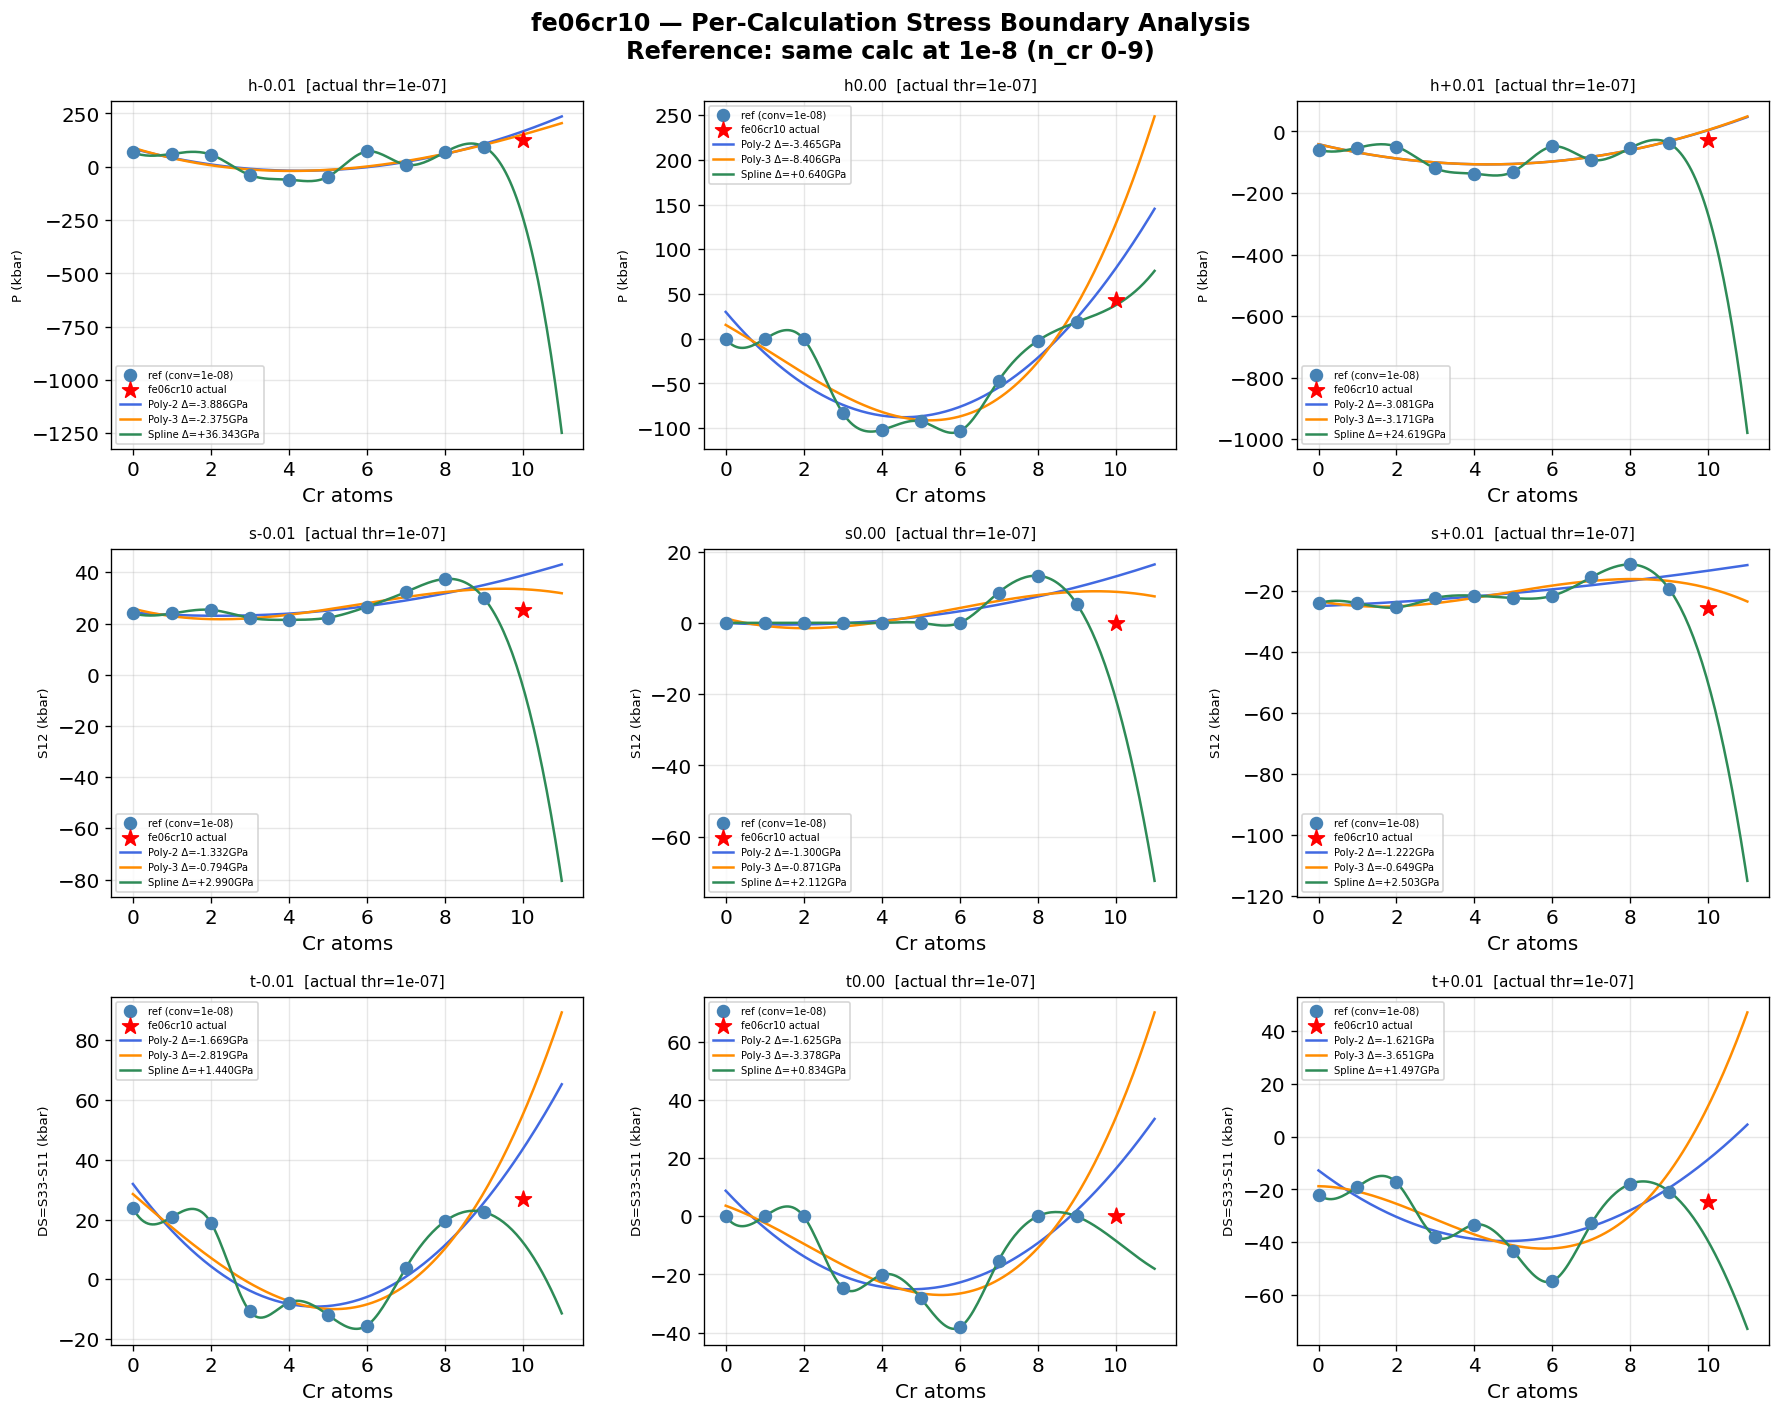

Saved: uncertainty_fe06cr10_boundary.png


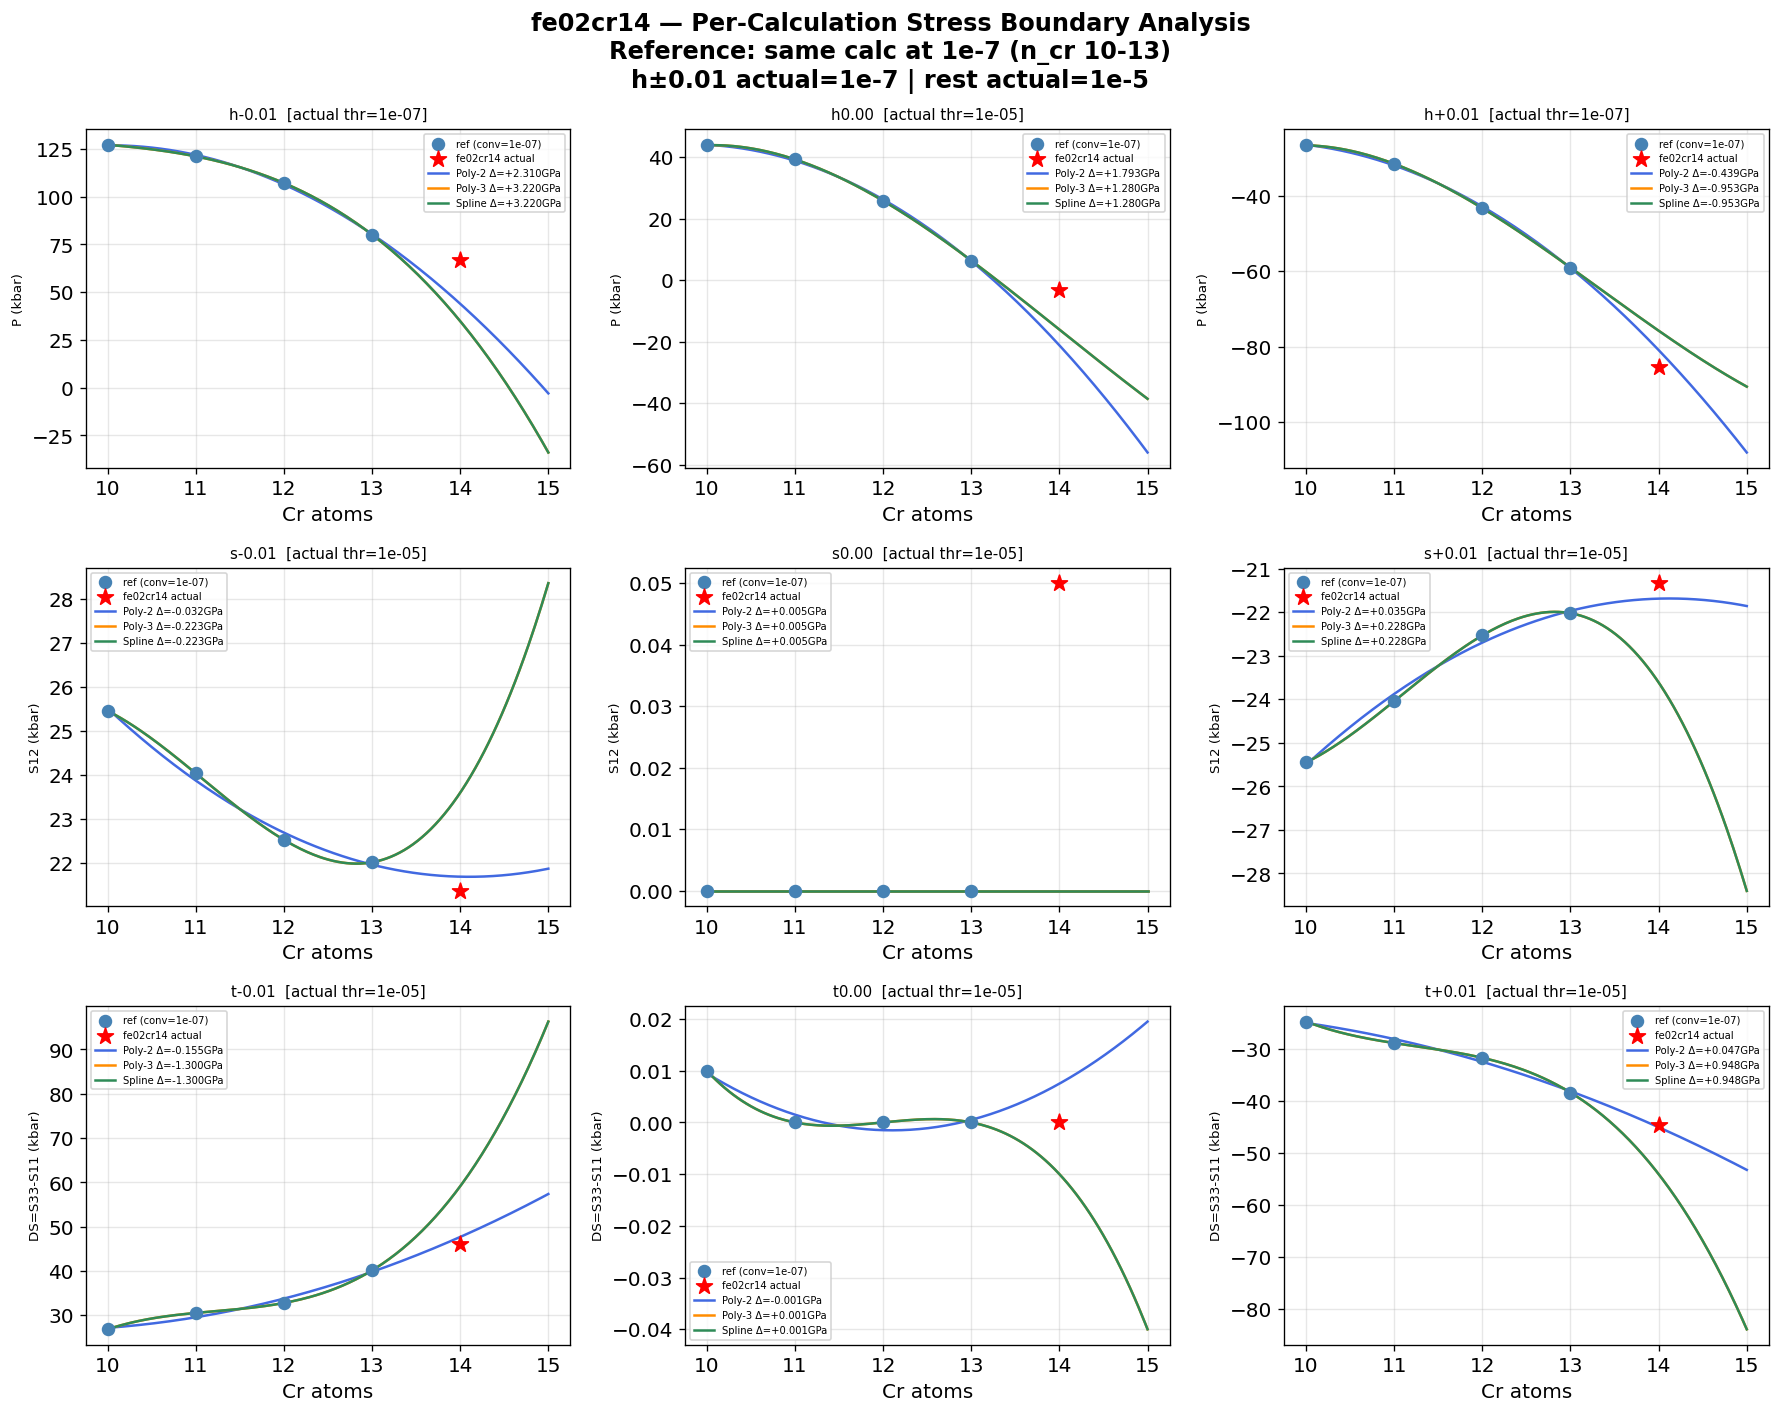

Saved: uncertainty_fe02cr14_boundary.png

── fe02cr14 h0.00 direct comparison (no interpolation) ──
  P(conv_thr=1e-5) = -3.250 kbar
  P(conv_thr=1e-7) = -0.960 kbar
  Δ = -0.2290 GPa  (exact, from thr7 file)


In [27]:
# ── fe06cr10 and fe02cr14 boundary analysis — raw stress per calculation ──────
#
# For each (strain_type, epsilon) calculation at the boundary tag:
#   - Collect same (stype, eps) stress values from reference tags at 1e-8 or 1e-7
#   - Fit poly-2, poly-3, spline on those reference points
#   - Predict at boundary tag composition
#   - Plot: reference points + 3 fit curves + actual value + Δ annotation
#
# fe06cr10 (n_cr=10): reference = same calc at 1e-8 (n_cr 0-9)
# fe02cr14 (n_cr=14): reference = same calc at 1e-7 (n_cr 10-13)

STRESS_LABELS = {
    'h': 'P (kbar)',
    's': 'S12 (kbar)',
    't': 'DS=S33-S11 (kbar)'
}

def plot_boundary_analysis(boundary_tag, boundary_ncr, ref_conv_thr,
                            results_df, title_suffix, save_name):
    """
    3×3 grid: rows = strain types (h, s, t), cols = epsilons (-0.01, 0.00, +0.01)
    Each panel: reference stress points + 3 fit curves + actual value + Δ
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    eps_list   = [-0.01, 0.00, 0.01]
    stype_list = ['h', 's', 't']

    for row_idx, stype in enumerate(stype_list):
        for col_idx, eps in enumerate(eps_list):
            ax  = axes[row_idx, col_idx]
            eps_str = f'{eps:+.2f}' if eps != 0.0 else '0.00'

            # Reference points from calc_df + dat files
            ref_mask = (
                (calc_df['strain_type'] == stype) &
                (calc_df['epsilon']     == eps) &
                (calc_df['conv_thr']    == ref_conv_thr) &
                (calc_df['tag']         != boundary_tag)
            )
            ref_tags = calc_df.loc[ref_mask, 'tag'].values
            ref_ncr  = np.array([
                df.loc[df['tag']==t, 'n_cr'].values[0] for t in ref_tags
            ], dtype=float)
            ref_stress = np.array([
                read_stress_value(t, stype, eps, DAT_ROOT) for t in ref_tags
            ], dtype=float)

            valid = ~np.isnan(ref_stress)
            xf = ref_ncr[valid]
            yf = ref_stress[valid]
            actual = read_stress_value(boundary_tag, stype, eps, DAT_ROOT)

            # Plot reference points
            ax.scatter(xf, yf, color='steelblue', s=50, zorder=5,
                       label=f'ref (conv={ref_conv_thr:.0e})')

            # Plot actual boundary tag value
            if actual is not None:
                ax.scatter(boundary_ncr, actual, color='red', s=100,
                           marker='*', zorder=8, label=f'{boundary_tag} actual')

            # Fit and plot 3 curves
            x_dense_local = np.linspace(xf.min(), boundary_ncr + 1, 200)
            model_cols = {'Poly-2':'royalblue','Poly-3':'darkorange','Spline':'seagreen'}
            model_fns  = {
                'Poly-2': lambda x,y,xp: fit_and_predict(x,y,xp,degree=2),
                'Poly-3': lambda x,y,xp: fit_and_predict(x,y,xp,degree=3),
                'Spline': lambda x,y,xp: spline_and_predict(x,y,xp),
            }
            if valid.sum() >= 3:
                for mname, mfn in model_fns.items():
                    try:
                        y_curve = mfn(xf, yf, x_dense_local)
                        y_pred  = mfn(xf, yf, np.array([float(boundary_ncr)]))[0]
                        delta   = (actual - y_pred) * 0.1 if actual is not None else None
                        ax.plot(x_dense_local, y_curve,
                                color=model_cols[mname], lw=1.5,
                                label=f'{mname} Δ={delta:+.3f}GPa' if delta is not None else mname)
                    except Exception:
                        pass

            # Retrieve actual conv_thr for this calc (fe02cr14 may be mixed)
            this_thr = calc_df.loc[
                (calc_df['tag']         == boundary_tag) &
                (calc_df['strain_type'] == stype) &
                (calc_df['epsilon']     == eps), 'conv_thr']
            thr_label = f'{this_thr.values[0]:.0e}' if len(this_thr) else '?'

            ax.set_title(f'{stype}{eps_str}  [actual thr={thr_label}]', fontsize=9)
            ax.set_xlabel('Cr atoms'); ax.set_ylabel(STRESS_LABELS[stype], fontsize=8)
            ax.legend(fontsize=6, loc='best')
            ax.grid(alpha=0.3)

    plt.suptitle(f'{boundary_tag} — Per-Calculation Stress Boundary Analysis\n{title_suffix}',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../analysis/{save_name}', bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_name}')


# ── Plot fe06cr10 ─────────────────────────────────────────────────────────────
plot_boundary_analysis(
    boundary_tag  = 'fe06cr10',
    boundary_ncr  = 10,
    ref_conv_thr  = 1e-8,
    results_df    = fe06_df,
    title_suffix  = 'Reference: same calc at 1e-8 (n_cr 0-9)',
    save_name     = 'uncertainty_fe06cr10_boundary.png'
)

# ── Plot fe02cr14 ─────────────────────────────────────────────────────────────
plot_boundary_analysis(
    boundary_tag  = 'fe02cr14',
    boundary_ncr  = 14,
    ref_conv_thr  = 1e-7,
    results_df    = fe02_df,
    title_suffix  = 'Reference: same calc at 1e-7 (n_cr 10-13)\nh±0.01 actual=1e-7 | rest actual=1e-5',
    save_name     = 'uncertainty_fe02cr14_boundary.png'
)

# ── Direct comparison for fe02cr14 h0.00 ─────────────────────────────────────
if h00_thr5 is not None and h00_thr7 is not None:
    print('\n── fe02cr14 h0.00 direct comparison (no interpolation) ──')
    print(f'  P(conv_thr=1e-5) = {h00_thr5:.3f} kbar')
    print(f'  P(conv_thr=1e-7) = {h00_thr7:.3f} kbar')
    print(f'  Δ = {(h00_thr5 - h00_thr7)*0.1:+.4f} GPa  (exact, from thr7 file)')

---
## Part 7 — Summary Table and Recommended σ Values

Collects all empirical measurements into one table.
These become the justified inputs to `enrich_csv.py`.

**Reading guide:**
- Tier A: reference quality. σ = 1.0 GPa (baseline — no comparison available).
- Tier B: fe06cr10 boundary anomaly → σ for Tier A→B transition.
- Tier C: thr7 comparison (indicator only, see Part 3 limitation).
- Tier D: residuals from Part 5 → empirical σ, range across models.
- AFM effect: documented separately as a qualitative flag, not a σ value,
  because no controlled FM/AFM comparison exists in this dataset.


In [28]:
# ── Collect all empirical measurements ───────────────────────────────────────

# σ_thr from per-calculation stress interpolation (fe06cr10 and fe02cr14)
# fe06cr10: all calcs at 1e-7 → σ from interpolation residuals
sigma_1e7_calcs = {}
if len(fe06_df) > 0:
    for col in ['delta_Poly-2_gpa', 'delta_Poly-3_gpa', 'delta_Spline_gpa']:
        sigma_1e7_calcs[col] = fe06_df[col].abs().mean()
    sigma_1e7_mean = round(np.mean(list(sigma_1e7_calcs.values())), 3)
    sigma_1e7_max  = round(fe06_df[
        ['delta_Poly-2_gpa','delta_Poly-3_gpa','delta_Spline_gpa']
    ].abs().max().max(), 3)
else:
    sigma_1e7_mean = float('nan')
    sigma_1e7_max  = float('nan')

# fe02cr14: separate 1e-7 calcs (h±0.01) from 1e-5 calcs
if len(fe02_df) > 0:
    fe02_1e7 = fe02_df[fe02_df['actual_conv_thr'] == 1e-7]
    fe02_1e5 = fe02_df[fe02_df['actual_conv_thr'] == 1e-5]
    delta_cols = ['delta_Poly-2_gpa','delta_Poly-3_gpa','delta_Spline_gpa']
    sigma_1e5_mean = round(fe02_1e5[delta_cols].abs().mean().mean(), 3) \
                     if len(fe02_1e5) > 0 else float('nan')
    sigma_1e5_max  = round(fe02_1e5[delta_cols].abs().max().max(), 3) \
                     if len(fe02_1e5) > 0 else float('nan')
    # Direct comparison h0.00 thr7
    sigma_1e5_direct = round(abs(h00_thr5 - h00_thr7) * 0.1, 4) \
                       if (h00_thr5 is not None and h00_thr7 is not None) else float('nan')
else:
    sigma_1e5_mean   = float('nan')
    sigma_1e5_max    = float('nan')
    sigma_1e5_direct = float('nan')

# Tier D: residuals from poly/spline fits (Run 2 — excluded from fit)
tier_d_sigma = {}
for tag in TIER_D_TAGS:
    sub = resid_df[resid_df['tag'] == tag]
    tier_d_sigma[tag] = {
        tname: {
            'max':  sub[sub['target']==tname]['abs_residual_gpa'].max(),
            'mean': sub[sub['target']==tname]['abs_residual_gpa'].mean(),
        }
        for tname in TARGETS
    }

# ── Print summary ─────────────────────────────────────────────────────────────
print('='*70)
print('EMPIRICAL UNCERTAINTY SUMMARY — per-calculation ground truth')
print('='*70)

print('\n── conv_thr=1e-8, FM init (reference quality) ──')
print('  σ = 1.0 GPa  [baseline — no comparison available]')
print('  All other σ values measured relative to this.')

print('\n── conv_thr=1e-7, FM init ──')
print('  Source: fe06cr10 per-calculation stress interpolation')
print('  Reference = same (stype, eps) calcs at 1e-8 from n_cr 0-9')
print(f'  σ mean across all 9 calcs × 3 models = {sigma_1e7_mean:.3f} GPa')
print(f'  σ max  across all 9 calcs × 3 models = {sigma_1e7_max:.3f} GPa')
if len(fe06_df) > 0:
    print('  Per-calculation breakdown:')
    print(fe06_df[['strain_type','epsilon',
                   'delta_Poly-2_gpa','delta_Poly-3_gpa',
                   'delta_Spline_gpa']].to_string(index=False))
print('  Caveat: Δ conflates threshold noise with physics non-linearity at that composition.')

print('\n── conv_thr=1e-5, AFM init (fe02cr14 partial, fe01cr15, fe00cr16) ──')
print('  Source 1: fe02cr14 per-calculation stress interpolation (1e-5 calcs)')
print('  Reference = same (stype, eps) calcs at 1e-7 from n_cr 10-13')
print(f'  σ mean across 1e-5 calcs × 3 models = {sigma_1e5_mean:.3f} GPa')
print(f'  σ max  across 1e-5 calcs × 3 models = {sigma_1e5_max:.3f} GPa')
print(f'  Source 2: fe02cr14 h0.00 direct comparison (thr5 vs thr7):')
print(f'  Δ = {sigma_1e5_direct:.4f} GPa  [exact — no interpolation]')
if len(fe02_1e5) > 0:
    print('  Per-calculation breakdown (1e-5 calcs):')
    print(fe02_1e5[['strain_type','epsilon',
                    'delta_Poly-2_gpa','delta_Poly-3_gpa',
                    'delta_Spline_gpa']].to_string(index=False))
print('  AFM init effect: unquantified — no controlled FM/AFM comparison exists.')

print('\n── Geometry uncertainty (vcr final SCF not converged) ──')
vcr_failed_tags = vcr_df[~vcr_df['final_scf_ok']]['tag'].tolist()
print(f'  Affects all calculations of: {vcr_failed_tags}')
for tag in TIER_D_TAGS:
    vcr_row = vcr_df[vcr_df['tag']==tag].iloc[0]
    print(f'\n  {tag}  [fail_reason: {vcr_row["fail_reason"]}]')
    print(f'  Empirical σ from poly/spline residuals (excluded from fit):')
    for tname in TARGETS:
        v = tier_d_sigma[tag][tname]
        print(f'    {tname}: mean={v["mean"]:.2f} GPa  max={v["max"]:.2f} GPa')

print('\n── AFM initialisation effect ──')
afm_tags = sorted(calc_df[calc_df['mag_init']=='AFM']['tag'].unique().tolist())
print(f'  Tags with AFM init in any calculation: {afm_tags}')
print('  No controlled FM/AFM comparison available. Cannot be quantified.')
print('  Carried as qualitative flag (afm_init) in per_calc_uncertainty.csv.')

# ── σ_thr mapping — derived from empirical measurements ──────────────────────
sigma_thr_map = {
    1e-8: 1.0,
    1e-7: sigma_1e7_mean if not np.isnan(sigma_1e7_mean) else 2.0,
    1e-5: sigma_1e5_mean if not np.isnan(sigma_1e5_mean) else float('nan'),
}

# ── Per-calculation uncertainty table ────────────────────────────────────────
def feeds_constant(strain_type, epsilon):
    if strain_type == 'vcr':   return 'geometry'
    if epsilon == 0.0:         return 'reference'
    if strain_type == 'h':     return 'C11+2C12'
    if strain_type == 't':     return 'C11-C12'
    if strain_type == 's':     return 'C44'
    return 'unknown'

vcr_ok = vcr_df.set_index('tag')['final_scf_ok'].to_dict()

unc_rows = []
for _, row in calc_df.iterrows():
    tag        = row['tag']
    stype      = row['strain_type']
    eps        = row['epsilon']
    conv_thr   = row['conv_thr']
    mag        = row['mag_init']
    file_found = row['file_found']
    vcr_failed = not vcr_ok.get(tag, True)
    afm        = (mag == 'AFM')
    sigma_thr  = sigma_thr_map.get(conv_thr, float('nan')) if file_found else float('nan')
    constant   = feeds_constant(stype, eps)

    sources = []
    if not file_found:
        sources.append('file_missing')
    else:
        thr_labels = {1e-8: 'conv_thr=1e-8(baseline)',
                      1e-7: 'conv_thr=1e-7(empirical)',
                      1e-5: 'conv_thr=1e-5(empirical)'}
        sources.append(thr_labels.get(conv_thr, f'conv_thr={conv_thr:.0e}'))
    if afm:
        sources.append('AFM_init(unquantified)')
    if vcr_failed:
        sources.append('vcr_geometry(propagated)')

    unc_rows.append({
        'tag':                row['tag'],
        'n_cr':               row['n_cr'],
        'strain_type':        stype,
        'epsilon':            eps,
        'filename':           row['filename'],
        'conv_thr':           conv_thr,
        'mag_init':           mag,
        'feeds_constant':     constant,
        'sigma_thr_gpa':      sigma_thr,
        'afm_init':           afm,
        'vcr_geometry_flag':  vcr_failed,
        'uncertainty_sources': ' | '.join(sources),
    })

unc_df = pd.DataFrame(unc_rows).sort_values(['n_cr','strain_type','epsilon'])
unc_df.to_csv('../analysis/per_calc_uncertainty.csv', index=False)
print(f'\nSaved: per_calc_uncertainty.csv ({len(unc_df)} rows)')

# ── empirical_sigma.csv — grouped by (conv_thr, afm_init) ────────────────────
notes_map = {
    1e-8: 'Baseline. No direct comparison. All others relative to this.',
    1e-7: 'fe06cr10 per-calc stress interpolation from 1e-8 reference. '
           'Conflates threshold noise with physics non-linearity.',
    1e-5: 'fe02cr14 per-calc stress interpolation from 1e-7 reference + '
           'direct h0.00 thr7 comparison. AFM effect unquantified separately.',
}
sigma_rows = []
for (conv_thr, afm), grp in unc_df[unc_df['strain_type']!='vcr'].groupby(
        ['conv_thr','afm_init']):
    tags = sorted(grp['tag'].unique().tolist())
    sigma_rows.append({
        'conv_thr':      conv_thr,
        'afm_init':      afm,
        'n_calcs':       len(grp),
        'tags':          ', '.join(tags),
        'sigma_thr_gpa': sigma_thr_map.get(conv_thr, float('nan')),
        'basis':         notes_map.get(conv_thr, 'unknown'),
    })

# Tier D geometry rows — per tag
for tag in TIER_D_TAGS:
    vcr_row  = vcr_df[vcr_df['tag']==tag].iloc[0]
    max_mean = max(tier_d_sigma[tag][t]['mean'] for t in TARGETS)
    sigma_rows.append({
        'conv_thr':      float('nan'),
        'afm_init':      unc_df[unc_df['tag']==tag]['afm_init'].iloc[0],
        'n_calcs':       len(unc_df[unc_df['tag']==tag]),
        'tags':          tag,
        'sigma_thr_gpa': round(max_mean, 2),
        'basis':         f'vcr_geometry — {vcr_row["fail_reason"]} — '
                         f'poly/spline residual mean across targets and models',
    })

sigma_df = pd.DataFrame(sigma_rows)
sigma_df.to_csv('../analysis/empirical_sigma.csv', index=False)
print(f'Saved: empirical_sigma.csv')
print(sigma_df[['conv_thr','afm_init','n_calcs',
                'sigma_thr_gpa','basis']].to_string(index=False))

EMPIRICAL UNCERTAINTY SUMMARY — per-calculation ground truth

── conv_thr=1e-8, FM init (reference quality) ──
  σ = 1.0 GPa  [baseline — no comparison available]
  All other σ values measured relative to this.

── conv_thr=1e-7, FM init ──
  Source: fe06cr10 per-calculation stress interpolation
  Reference = same (stype, eps) calcs at 1e-8 from n_cr 0-9
  σ mean across all 9 calcs × 3 models = 4.381 GPa
  σ max  across all 9 calcs × 3 models = 36.343 GPa
  Per-calculation breakdown:
strain_type  epsilon  delta_Poly-2_gpa  delta_Poly-3_gpa  delta_Spline_gpa
          h   -1e-02            -4e+00            -2e+00             4e+01
          h    0e+00            -3e+00            -8e+00             6e-01
          h    1e-02            -3e+00            -3e+00             2e+01
          s   -1e-02            -1e+00            -8e-01             3e+00
          s    0e+00            -1e+00            -9e-01             2e+00
          s    1e-02            -1e+00            -6e-01     